# DAI Mission: Proposal & Final Submission
**Data & AI in Economics | TU Dortmund**

This notebook served first as the team's mission proposal and now also stands as the final deliverable.

> **Team size:** 3 students
> **Deliverable:** This Jupyter Notebook (proposal through final submission in one file)


> **LLM use disclosure:** Generative AI tools (ChatGPT / Claude) supported this project in three ways: drafting explanatory markdown text, debugging error messages, and talking through methodological choices such as how to structure the DoWhy causal graph and how to read refutation test output. Every data cleaning decision, model specification, parameter choice, and interpretation of results belongs to the team. Each AI suggested code snippet was reviewed, run, and checked against the actual data before being kept.


## 1. Team


| Role | Name | Student ID |
|------|------|------------|
| Lead | Usama Saleem | |
| Member | Zi Zhang | |
| Member | Ekin Yuecesan | |


## 2. Mission Title & Research Question


**Title:** Predicting Corporate Financial Distress from Accounting Ratios: A Causal ML Approach

**Research question:**
Can machine learning models trained on Compustat financial statement ratios predict corporate financial distress within a one year horizon more accurately than the classical Altman Z score, and to what extent does leverage *causally* raise distress probability rather than simply correlating with it?

**Why it matters:**
Corporate default is costly for creditors, employees, and the wider economy. Banks, rating agencies, and credit funds rely on distress models to price loans, set credit limits, and allocate capital. The classical Altman Z score (1968) uses five ratios chosen by hand, while modern ML can search across many ratios at once and capture nonlinear interactions between them. The harder question is whether high leverage actually causes default or only travels alongside it. A firm in trouble often borrows to survive, and firms with strong access to credit (typically larger, more profitable firms) tend to carry more long term debt while also being inherently safer. That makes leverage's relationship with distress confounded, and untangling it matters both for regulatory policy and for building models that are fair rather than just accurate. This project brings causal inference, supervised learning, and unsupervised learning together on the same financial dataset.


## 3. Data


**Source(s):**
Compustat North America (Fundamentals Annual), accessed via WRDS (Wharton Research Data Services), TU Dortmund institutional access. Usage is governed by the WRDS/Compustat data licence and is not for redistribution outside the research team.

**Unit of observation:** One row equals one firm fiscal year, identified by `gvkey` and `fyear`.

**Key variables:**

| Variable | Type | Role | Description |
|----------|------|------|--------------|
| `gvkey` | id | identifier | Compustat firm identifier |
| `fyear` | int | identifier | Fiscal year (derived from `datadate`) |
| `at` | float | feature input | Total assets |
| `act` | float | feature input | Current assets |
| `lct` | float | feature input | Current liabilities |
| `lt` | float | feature input | Total liabilities |
| `dltt` | float | feature input | Long term debt |
| `revt` | float | feature input | Total revenue |
| `ebit` / `ebitda` | float | feature input | Earnings before interest and tax / before interest, tax, depreciation and amortization |
| `ni` | float | feature input | Net income |
| `xint` | float | feature input | Interest expense |
| `ceq` | float | label driver | Common / book equity |
| `wcap`, `re` | float | feature input | Working capital, retained earnings |
| `sic` / `sich` | categorical | filter | Current / historical industry classification |
| `costat` | categorical | examined, not used | Compustat active/inactive flag |
| `distress` (engineered) | binary | **target** | 1 if firm transitions into distress next year |

**Potential data quality issues (identified and handled below):**
Negative current assets and negative revenue (both impossible values), EBIT exceeding EBITDA (impossible if depreciation and amortization is non negative), firms below a $1M total assets threshold (likely shell companies or data errors), fiscal year end changes that produce non comparable stub period years, extreme asset jumps from one year to the next (genuine M&A activity versus data errors), missing values in core variables, and a label persistence issue where firms already distressed in year *t* would otherwise be double counted as newly distressed in year *t+1*.


## Cell 1. Imports


In [1]:
import warnings, os
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, accuracy_score, f1_score,
                              precision_score, recall_score,
                              precision_recall_curve, average_precision_score)
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
print("Imports successful")

I0000 00:00:1782830342.046224    1235 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782830342.098735    1235 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782830343.927988    1235 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Imports successful


## Cell 2. Load Raw Data
The fiscal year (`fyear`) is not a column in the raw pull. It is derived from `datadate`, the fiscal period end date Compustat actually reports.


In [2]:
import os
df = pd.read_csv("data/compustat_raw.csv", low_memory=False)
print("Loaded successfully")
df["datadate"] = pd.to_datetime(df["datadate"])
df["fyear"] = df["datadate"].dt.year
print("Raw shape:", df.shape)
print("Years:", df.fyear.min(), "to", df.fyear.max())
print("Unique firms:", df.gvkey.nunique())

Loaded from: data/compustat_raw.csv
Raw shape: (220729, 25)
Years: 2000 to 2022
Unique firms: 25056


## Cell 3. Initial Filtering

**Fix applied here:** industry classification now uses `sich`, the historical SIC code Compustat assigns for that specific fiscal year, and only falls back to the current `sic` when `sich` is missing. This matters because a firm's business can change over a panel spanning 22 years, for example a conglomerate that exits manufacturing for financial services, so relying only on today's `sic` would misclassify its industry in earlier years. Checking this on the data: **74,798 rows (34%)** have `sic` not equal to `sich`, confirming this is a real distinction rather than a cosmetic one.

Standard academic finance filters are applied as well: drop duplicate firm years, exclude financial firms (SIC 6000 to 6999, since these follow different accounting rules) and utilities (SIC 4900 to 4999, since these have regulated capital structures), and restrict the sample to 2000 through 2022.


In [3]:
def initial_filter(df):
    n0 = len(df)
    df = df.copy()
    df["sich"] = df["sich"].fillna(df["sic"])
    df = df[(df["fyear"] >= 2000) & (df["fyear"] <= 2022)]
    df = df[~df["sich"].between(6000, 6999)]
    df = df[~df["sich"].between(4900, 4999)]
    df = df.drop_duplicates(subset=["gvkey", "fyear"], keep="first")
    n1 = len(df)
    print(f"Rows before: {n0:,}  after: {n1:,}  removed: {n0-n1:,}")
    print(f"Unique firms remaining: {df['gvkey'].nunique():,}")
    return df

df = initial_filter(df)

Rows before: 220,729  after: 137,470  removed: 83,259
Unique firms remaining: 16,107


## Cell 4. Total Assets and Impossible Value Cleaning

**What this does:** drops rows that are either too small to plausibly be a real operating business, or contain values that are mathematically impossible, meaning they reflect data errors rather than unusual firms.

Four checks are applied in sequence.

1. **Total assets**: drops rows where `at` is missing, zero, negative, or under $1M. There is no single universal threshold in the distress prediction literature. Studies vary widely in how they define a minimum firm size, some use no minimum at all, others use revenue or employee count instead of total assets, and others restrict attention to manufacturing firms with no formal floor. The $1M total assets floor used here is a practical choice for this dataset specifically: rows this small in Compustat are almost always shell companies with no real operations or outright data entry errors rather than genuine small businesses, since most operating companies large enough to be covered by Compustat in the first place report total assets well above this level. Excluding them keeps the sample focused on real operating firms without imposing a much stricter size cutoff that would also remove legitimate small caps.
2. **Negative current assets** (`act < 0`): impossible, since current assets such as cash, receivables, and inventory cannot be negative.
3. **Negative revenue** (`revt < 0`): also impossible for normal operating revenue, almost certainly a restatement or reporting artifact.
4. **EBIT above EBITDA**: impossible if depreciation and amortization is non negative, since EBIT equals EBITDA minus depreciation and amortization. Six rows violate this, one with a 3,248 unit gap, a clear data entry error.

Each step prints how many rows it removed, and the function prints the final shape of the dataframe so the cumulative effect of all four checks is visible.


In [4]:
def clean_impossible_values(df):
    n0 = len(df)
    df = df[df["at"].notna() & (df["at"] >= 1)]
    n_assets = n0 - len(df)

    n1 = len(df)
    df = df[~(df["act"] < 0)]
    n_act = n1 - len(df)

    n2 = len(df)
    df = df[~(df["revt"] < 0)]
    n_revt = n2 - len(df)

    n3 = len(df)
    ebit_violation = df["ebit"].notna() & df["ebitda"].notna() & (df["ebit"] > df["ebitda"])
    df = df[~ebit_violation]
    n_ebit = n3 - len(df)

    print(f"Dropped for total assets (NaN/0/neg/<$1M): {n_assets:,}")
    print(f"Dropped for negative current assets (act<0): {n_act:,}")
    print(f"Dropped for negative revenue (revt<0): {n_revt:,}")
    print(f"Dropped for EBIT > EBITDA (impossible if D&A>=0): {n_ebit:,}")
    print(f"Shape after: {df.shape}")
    return df

df = clean_impossible_values(df)

Dropped for total assets (NaN/0/neg/<$1M): 13,068
Dropped for negative current assets (act<0): 7
Dropped for negative revenue (revt<0): 26
Dropped for EBIT > EBITDA (impossible if D&A>=0): 6
Shape after: (124363, 25)


## Cell 5. Fiscal Year End Change Detection

**999 firms changed their fiscal year end month (`fyr`) at least once** across the panel. The transition year for these firms has a stub period, often shorter or longer than 12 months, which makes that year's flow variables (`revt`, `ebitda`, `ni`, `xint`) not comparable to a normal twelve month fiscal year. A six month `ebitda` figure would look like a profit collapse next to a normal year's twelve month figure purely because of the period length, not because of any real change in the business.

**Fix:** flag the specific transition firm year and exclude just that one row. The firm itself stays in the panel; only its distorted transition year is removed.


In [5]:
def flag_and_exclude_fyr_changes(df):
    df = df.sort_values(["gvkey", "fyear"]).copy()
    df["fyr_prev"] = df.groupby("gvkey")["fyr"].shift(1)
    df["fyr_change_flag"] = ((df["fyr_prev"].notna()) & (df["fyr"] != df["fyr_prev"])).astype(int)

    n_flagged = df["fyr_change_flag"].sum()
    n_firms_affected = df.loc[df["fyr_change_flag"]==1, "gvkey"].nunique()
    print(f"Fiscal year end transition years flagged: {n_flagged:,} ({n_firms_affected:,} firms affected)")

    n_before = len(df)
    df = df[df["fyr_change_flag"] == 0].copy()
    print(f"Excluded (stub period transition years only, firms kept): {n_before - len(df):,}")
    df = df.drop(columns=["fyr_prev", "fyr_change_flag"])
    return df

df = flag_and_exclude_fyr_changes(df)

Fiscal year end transition years flagged: 628 (613 firms affected)
Excluded (stub period transition years only, firms kept): 628


## Cell 6. Extreme Asset Jump Flag (flagged, not removed)

**4,646 firm years show asset growth above 500% or asset shrinkage above 80%** from one year to the next, almost certainly reflecting large M&A activity, divestitures, or restatements rather than organic business change.

**Why this is flagged but not dropped, unlike the previous two checks:** a firm genuinely can triple in size by acquiring another company, and that is a real economic event rather than a data error. Removing these rows entirely would silently delete real signal the model might legitimately need, for example distress sometimes follows a poorly financed, overleveraged acquisition. The flag stays in the dataset so a robustness check excluding these rows remains possible later, without baking that exclusion into the main analysis by default.


In [6]:
def flag_extreme_asset_jumps(df):
    df = df.sort_values(["gvkey", "fyear"]).copy()
    df["at_prev"] = df.groupby("gvkey")["at"].shift(1)
    growth = (df["at"] - df["at_prev"]) / df["at_prev"]
    df["extreme_asset_jump_flag"] = ((growth > 5) | (growth < -0.8)).fillna(False).astype(int)
    n_flagged = df["extreme_asset_jump_flag"].sum()
    print(f"Extreme asset jump firm years flagged (kept, not removed): {n_flagged:,}")
    df = df.drop(columns=["at_prev"])
    return df

df = flag_extreme_asset_jumps(df)

Extreme asset jump firm years flagged (kept, not removed): 1,445


## Cell 7. Missing Value Treatment

Strategy:

1. `xint`, `dltt`, `wcap`, `re`: filled with **0**, since a missing value genuinely tends to mean "no debt" or "no balance" for these specific Compustat fields.
2. `ebitda`, `ni`, `act`, `lct`, `revt`, `ebit`, `lt`: filled with the **industry year median** (grouped by `sich` and `fyear`), which preserves cross sectional structure instead of simply zeroing out a real operating figure.
3. **`ceq` is deliberately not imputed.** It directly determines the distress label through `ceq < 0`. Filling a missing equity value with a typically positive industry median would silently convert "we do not know" into "definitely healthy" for the one variable the label depends on most. Rows missing `ceq` are dropped instead.


In [7]:
def handle_missing_values(df):
    df = df.copy()
    for col in ["xint", "dltt", "wcap", "re"]:
        n_filled = df[col].isna().sum()
        df[col] = df[col].fillna(0)
        print(f"  {col:<6}: filled {n_filled:,} NaNs with 0 (economic zero)")

    median_fill_vars = ["ebitda", "ni", "act", "lct", "revt", "ebit", "lt"]
    for var in median_fill_vars:
        n_before = df[var].isna().sum()
        df[var] = df.groupby(["sich", "fyear"])[var].transform(lambda x: x.fillna(x.median()))
        df[var] = df[var].fillna(0)
        print(f"  {var:<6}: filled {n_before:,} NaNs with industry year median")

    n_ceq = df["ceq"].isna().sum()
    df = df[df["ceq"].notna()]
    print(f"  ceq   : dropped {n_ceq:,} rows with missing equity (not imputed)")
    print(f"\nShape after missing value treatment: {df.shape}")
    return df

df = handle_missing_values(df)

  xint  : filled 9,183 NaNs with 0 (economic zero)
  dltt  : filled 405 NaNs with 0 (economic zero)
  wcap  : filled 2,243 NaNs with 0 (economic zero)
  re    : filled 3,525 NaNs with 0 (economic zero)


  ebitda: filled 674 NaNs with industry year median


  ni    : filled 394 NaNs with industry year median


  act   : filled 2,176 NaNs with industry year median


  lct   : filled 2,151 NaNs with industry year median


  revt  : filled 389 NaNs with industry year median


  ebit  : filled 394 NaNs with industry year median


  lt    : filled 289 NaNs with industry year median
  ceq   : dropped 298 rows with missing equity (not imputed)

Shape after missing value treatment: (123437, 26)


## Cell 8. Data Quality Note: `costat` (Active/Inactive Status)

This field looks tempting at first glance: `'I'` (inactive) means the firm has exited Compustat's coverage, which sounds like it could double as a free bankruptcy signal.

**Why it is not used for the label:** Compustat's `costat` field does not distinguish *why* a firm exited. A firm can become inactive because it went bankrupt, or because it was acquired, went private, or voluntarily delisted, all common, healthy corporate events with nothing to do with financial distress. Using `costat='I'` directly would mislabel a large number of perfectly healthy acquired firms as distressed. The academic literature handles this by using CRSP delisting codes, which do distinguish bankruptcy from merger, rather than Compustat's own status flag. That data is not part of this pull.


In [8]:
print("costat (Compustat active/inactive status) distribution:")
print(df["costat"].value_counts())
print()
print("NOTE: 'I' (inactive) can mean bankruptcy, acquisition, going private,")
print("or voluntary delisting; Compustat does not distinguish the reason.")
print("We do NOT use costat in the distress label for this reason (see markdown).")

costat (Compustat active/inactive status) distribution:
costat
I    62262
A    61175
Name: count, dtype: int64

NOTE: 'I' (inactive) can mean bankruptcy, acquisition, going private,
or voluntary delisting; Compustat does not distinguish the reason.
We do NOT use costat in the distress label for this reason (see markdown).


## Cell 9. Distress Label: Construction and Persistence Fix

**Definition used (a proxy in the style of Altman and Dichev, 1998):** a firm is distressed next year if, in year *t+1*, either of the following holds:

1. `ceq < 0`, negative book equity, technical insolvency, or
2. `ebitda < xint`, operating earnings cannot cover interest payments

**The persistence fix (critical):** the raw version of this label does not check whether the firm was *already* distressed in year *t* itself. Checking this on the actual data: **85.6% of raw positive labels were firms already in distress**. They had not transitioned into distress, they had simply stayed there. Those firm years are excluded, so the task becomes "starting from a currently healthy firm, does it tip into distress next year," a genuinely harder and more meaningful prediction problem.

**Flip flag (kept, not removed):** 412 firms flip between distressed and healthy 5 or more times across the panel. These are flagged for transparency but not dropped, since removing volatile firms would introduce survivorship bias. Real distress genuinely involves firms cycling between near failure and recovery.


In [9]:
def build_distress_label(df):
    df = df.sort_values(["gvkey", "fyear"]).copy()

    df["distress_signal"] = ((df["ceq"] < 0) | (df["ebitda"] < df["xint"])).astype(int)
    df["signal_next"]     = df.groupby("gvkey")["distress_signal"].shift(-1)
    df["fyear_next"]      = df.groupby("gvkey")["fyear"].shift(-1)
    consecutive = (df["fyear_next"] == df["fyear"] + 1)
    df = df[consecutive].copy()
    df["distress"] = df["signal_next"].astype(int)

    pos = df[df["distress"] == 1]
    already_pct = (pos["distress_signal"] == 1).mean() if len(pos) else 0
    print(f"Rows with valid forward label: {len(df):,}")
    print(f"Distress rate (before persistence fix): {df['distress'].mean():.4f}")
    print(f"Of positive labels, {already_pct:.1%} were ALREADY distressed in year t (persistence)")

    df["signal_shift"] = df.groupby("gvkey")["distress_signal"].diff().abs()
    flip_counts = df.groupby("gvkey")["signal_shift"].sum()
    high_flip_firms = set(flip_counts[flip_counts >= 5].index)
    df["high_flip_flag"] = df["gvkey"].isin(high_flip_firms).astype(int)
    print(f"Firms that flip frequently flagged (not removed): {len(high_flip_firms):,}")

    n_before = len(df)
    df = df[df["distress_signal"] == 0].copy()
    print(f"Excluded already distressed firm years: {n_before - len(df):,}")
    df = df.drop(columns=["distress_signal","signal_next","fyear_next","signal_shift"])

    print(f"\nFinal sample: {len(df):,} rows")
    print(f"Distress rate (genuine new transitions only): {df['distress'].mean():.4f}")
    return df

df = build_distress_label(df)

Rows with valid forward label: 106,968
Distress rate (before persistence fix): 0.3754
Of positive labels, 85.6% were ALREADY distressed in year t (persistence)
Firms that flip frequently flagged (not removed): 406
Excluded already distressed firm years: 40,167

Final sample: 66,801 rows
Distress rate (genuine new transitions only): 0.0867


## Cell 10. Feature Engineering: Financial Ratios

`long_term_leverage` (`dltt/at`) and `total_liabilities_ratio` (`lt/at`) are kept as two **separate, clearly named** features, since they capture different things: long term debt burden specifically versus all claims against the firm.

| Ratio | Formula | Captures |
|---|---|---|
| `long_term_leverage` | `dltt/at` | long term debt burden specifically |
| `total_liabilities_ratio` | `lt/at` | all claims against the firm, not just debt |
| `roa` | `ni/at` | profitability |
| `coverage` | `ebitda/xint`, capped between minus 50 and 100 | ability to service debt |
| `current_ratio` | `act/lct` | short term liquidity |
| `wcap_ratio` | `wcap/at` | working capital buffer |
| `asset_turnover` | `revt/at` | operating efficiency |
| `retained_ratio` | `re/at` | accumulated profitability cushion |
| `profit_margin` | `ebitda/revt` | operating margin |
| `size_log` | `log(at)` | firm size |
| `altman_z` | weighted combination | classic distress benchmark |

**Winsorization is intentionally not done in this cell.** It happens later, in the train, validation, and test split section, where it is computed on training data only to avoid look ahead bias.


In [10]:
def engineer_ratios(df):
    eps = 1e-6
    df = df.copy()
    df["long_term_leverage"]      = df["dltt"] / df["at"]
    df["total_liabilities_ratio"] = df["lt"] / df["at"]
    df["roa"]                     = df["ni"] / df["at"]
    df["coverage"]                = (df["ebitda"] / (df["xint"] + eps)).clip(-50, 100)
    df["current_ratio"]           = df["act"] / df["lct"].replace(0, np.nan)
    df["wcap_ratio"]               = df["wcap"] / df["at"]
    df["asset_turnover"]          = df["revt"] / df["at"]
    df["retained_ratio"]          = df["re"] / df["at"]
    df["profit_margin"]           = df["ebitda"] / df["revt"].replace(0, np.nan)
    df["size_log"]                = np.log(df["at"])
    df["altman_z"] = (
        1.2 * df["wcap_ratio"] +
        1.4 * df["retained_ratio"] +
        3.3 * (df["ebit"] / df["at"]) +
        0.6 * (df["ceq"] / df["lt"].replace(0, np.nan)) +
        1.0 * df["asset_turnover"]
    )

    ratio_cols = ["long_term_leverage","total_liabilities_ratio","roa","coverage",
                  "current_ratio","wcap_ratio","asset_turnover","retained_ratio",
                  "profit_margin","size_log","altman_z"]

    for c in ratio_cols:
        df[c] = df[c].replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=ratio_cols)

    print(f"Ratios engineered: {ratio_cols}")
    print(f"Final modelling sample: {df.shape}  | unique firms: {df['gvkey'].nunique():,}")
    print("\n(Unwinsorized; winsorization happens after the train, validation, and test split)")
    print(df[ratio_cols + ["distress"]].describe().T[["mean","std","min","max"]])
    return df, ratio_cols

df, ratio_cols = engineer_ratios(df)

Ratios engineered: ['long_term_leverage', 'total_liabilities_ratio', 'roa', 'coverage', 'current_ratio', 'wcap_ratio', 'asset_turnover', 'retained_ratio', 'profit_margin', 'size_log', 'altman_z']
Final modelling sample: (66580, 39)  | unique firms: 8,508

(Unwinsorized; winsorization happens after the train, validation, and test split)


                              mean        std         min           max
long_term_leverage        0.189745   0.185578    0.000000      0.934853
total_liabilities_ratio   0.495467   0.264011    0.000074     20.586461
roa                       0.052702   0.199704   -8.614779     21.789094
coverage                 33.325436  38.365823  -50.000000    100.000000
current_ratio             3.002554  56.070500    0.000000  13545.000000
wcap_ratio                0.219747   0.222401   -0.836451      0.999926
asset_turnover            1.158338   4.693673    0.000109    982.442128
retained_ratio           -0.019389   1.399144 -107.260681      2.661569
profit_margin             0.300712  15.797083    0.000000   3583.800000
size_log                  6.635335   2.234685    0.011929     13.773421
altman_z                  3.098342  33.954737 -144.814951   8126.400480
distress                  0.086768   0.281497    0.000000      1.000000


## Cell 11. Distress Rate Over Time

**8.7% of healthy firm years** transition into genuine new distress the following year. The rate spikes around the dot com bust (2000 to 2001, 14.6% and 12.2%) and around the lead up to the 2008 financial crisis (2007 to 2008), and again notably in 2019 (13.9%), predating the pandemic. This pattern suggests credit stress late in the economic cycle was already building before COVID hit.


Distress rate by year:
fyear
2000    0.146
2001    0.121
2002    0.078
2003    0.063
2004    0.080
2005    0.077
2006    0.080
2007    0.106
2008    0.109
2009    0.058
2010    0.064
2011    0.077
2012    0.072
2013    0.071
2014    0.097
2015    0.083
2016    0.061
2017    0.061
2018    0.083
2019    0.138
2020    0.081
2021    0.085
Name: distress, dtype: float64


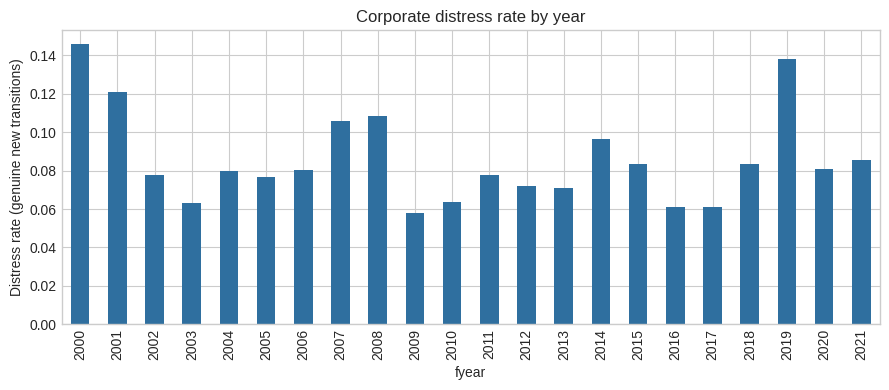

In [11]:
print("Distress rate by year:")
print(df.groupby("fyear")["distress"].mean().round(3))

fig, ax = plt.subplots(figsize=(9,4))
df.groupby("fyear")["distress"].mean().plot(kind="bar", ax=ax, color="#2f6f9f")
ax.set_ylabel("Distress rate (genuine new transitions)")
ax.set_title("Corporate distress rate by year")
plt.tight_layout(); plt.savefig("figs/01_distress_by_year.png", dpi=130); plt.show()

## Cell 12. Correlations Between Ratios and Distress

`size_log` and `retained_ratio` are the strongest negative correlates. Smaller firms with thinner accumulated profit cushions are most likely to tip into distress. Both leverage measures show only weak raw correlation here. Their relationship with distress turns out to depend heavily on controlling for other factors, as the causal section below shows.


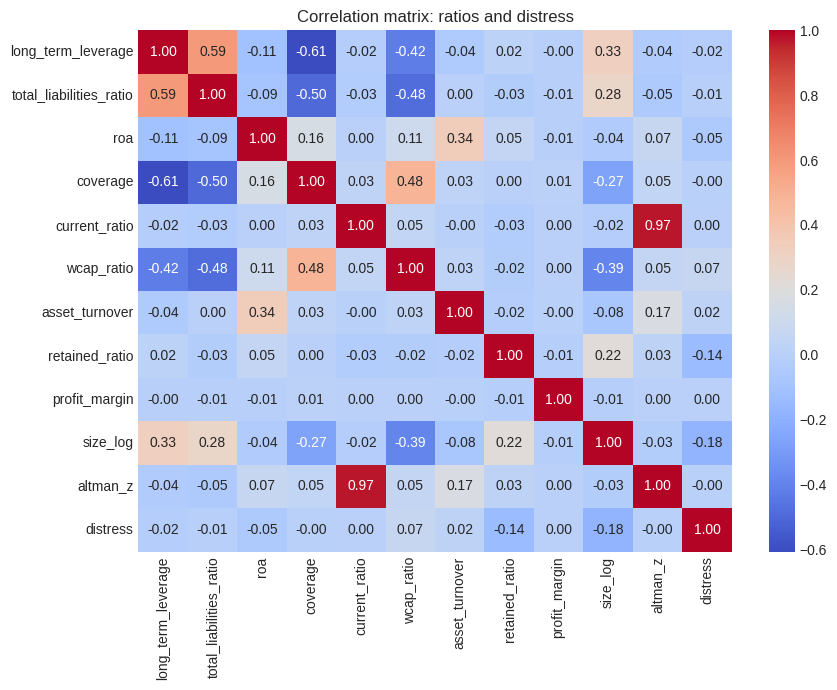

size_log                  -0.184739
retained_ratio            -0.138049
roa                       -0.053169
long_term_leverage        -0.020319
total_liabilities_ratio   -0.009321
altman_z                  -0.003511
coverage                  -0.001037
current_ratio              0.003415
profit_margin              0.004726
asset_turnover             0.020747
wcap_ratio                 0.066656
dtype: float64


In [12]:
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(df[ratio_cols+["distress"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation matrix: ratios and distress")
plt.tight_layout(); plt.savefig("figs/02_corr_heatmap.png", dpi=130); plt.show()
print(df[ratio_cols].corrwith(df["distress"]).sort_values())

## Cell 13. Target Variable Overview

Before moving on to modelling, the target variable itself is examined more closely: whether a healthy firm transitions into genuine new distress the following year. The distress rate was already reported by year in Cell 11. Here the overall balance of the label is checked and the missing value treatment from Cell 7 is confirmed to have left no gaps in the modelling columns.


Missing values in modelling columns (should be zero):
0

Descriptive statistics for the ratio features and the label:
                              mean        std         min       25%  \
long_term_leverage        0.189745   0.185578    0.000000  0.007548   
total_liabilities_ratio   0.495467   0.264011    0.000074  0.325037   
roa                       0.052702   0.199704   -8.614779  0.011922   
coverage                 33.325436  38.365823  -50.000000  4.995020   
current_ratio             3.002554  56.070500    0.000000  1.264958   
wcap_ratio                0.219747   0.222401   -0.836451  0.049784   
asset_turnover            1.158338   4.693673    0.000109  0.553762   
retained_ratio           -0.019389   1.399144 -107.260681 -0.035157   
profit_margin             0.300712  15.797083    0.000000  0.081335   
size_log                  6.635335   2.234685    0.011929  5.138637   
altman_z                  3.098342  33.954737 -144.814951  1.503890   
distress                  0.08

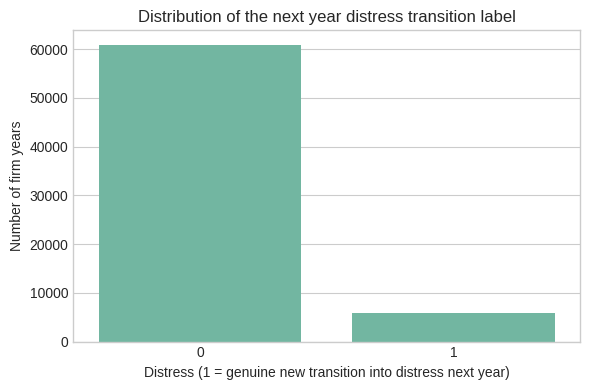

In [13]:
print("Missing values in modelling columns (should be zero):")
print(df[ratio_cols + ["distress"]].isna().sum().sum())

print("\nDescriptive statistics for the ratio features and the label:")
print(df[ratio_cols + ["distress"]].describe().T[["mean","std","min","25%","50%","75%","max"]])

distress_counts = df["distress"].value_counts()
distress_pct = df["distress"].value_counts(normalize=True) * 100
print("\nNext year distress transition label balance:")
print(pd.DataFrame({"count": distress_counts, "percentage": distress_pct.round(2)}))

fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=df, x="distress", ax=ax)
ax.set_title("Distribution of the next year distress transition label")
ax.set_xlabel("Distress (1 = genuine new transition into distress next year)")
ax.set_ylabel("Number of firm years")
plt.tight_layout(); plt.savefig("figs/09_distress_balance.png", dpi=130); plt.show()

## Cell 14. Leverage Distribution

`long_term_leverage` is the main explanatory variable in the research question, so its distribution is worth examining on its own before comparing it across distress groups. Leverage ratios are bounded below by zero with no fixed upper bound, so a right skewed distribution with a long right tail of highly leveraged firms is the expected shape. The limited view below clips the axis to the 1st and 99th percentile so the bulk of the distribution is visible without the extreme tail flattening the plot.


count    66580.000000
mean         0.189745
std          0.185578
min          0.000000
25%          0.007548
50%          0.152857
75%          0.307449
max          0.934853
Name: long_term_leverage, dtype: float64


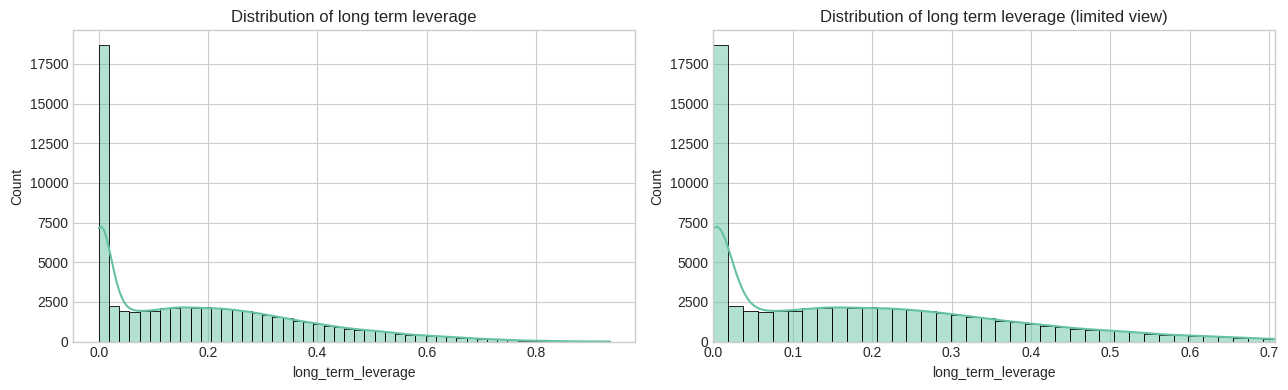

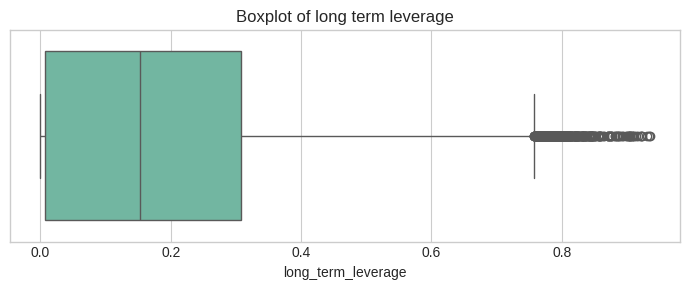

In [14]:
print(df["long_term_leverage"].describe())

fig, axes = plt.subplots(1, 2, figsize=(13,4))
sns.histplot(df["long_term_leverage"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of long term leverage")
axes[0].set_xlabel("long_term_leverage")

sns.histplot(df["long_term_leverage"], bins=50, kde=True, ax=axes[1])
axes[1].set_xlim(df["long_term_leverage"].quantile(0.01), df["long_term_leverage"].quantile(0.99))
axes[1].set_title("Distribution of long term leverage (limited view)")
axes[1].set_xlabel("long_term_leverage")
plt.tight_layout(); plt.savefig("figs/10_leverage_distribution.png", dpi=130); plt.show()

fig, ax = plt.subplots(figsize=(7,3))
sns.boxplot(x=df["long_term_leverage"], ax=ax)
ax.set_title("Boxplot of long term leverage")
plt.tight_layout(); plt.savefig("figs/11_leverage_boxplot.png", dpi=130); plt.show()

## Cell 15. Leverage and Financial Distress

Leverage is now compared between firms that transition into distress next year and firms that stay healthy. This comparison is descriptive only and, on its own, says nothing about causality. The causal inference section later in this notebook is what actually addresses whether leverage *causes* distress once confounders are taken into account.

**An openly surprising result worth sitting with rather than glossing over:** firm years that go on to a genuine new distress transition do not have higher raw leverage on average. If anything, the comparison runs the other way. Mean `long_term_leverage` is 0.191 for firms that stay healthy versus 0.178 for firms that transition into distress, and the gap is sharper at the median, 0.158 versus 0.078. Taken at face value, this would say leverage makes a firm *safer*, which contradicts both capital structure theory and the causal result found later in this notebook, where leverage raises distress risk once confounders are properly accounted for. This is not a contradiction so much as a demonstration of why a raw, unconditional comparison like this one is not trustworthy on its own. The relationship between leverage and distress here is most likely confounded by firm size, profitability, industry, and how the sample is constructed in the first place, since only firms large enough and established enough to be covered by Compustat appear at all, and larger, more creditworthy firms tend to carry more debt while also being safer for other reasons. The causal inference section is built specifically to address this kind of confounding rather than read the raw group means at face value.


          count      mean    median       std  min       max
distress                                                    
0         60803  0.190907  0.157610  0.182478  0.0  0.933722
1          5777  0.177512  0.078363  0.215157  0.0  0.934853


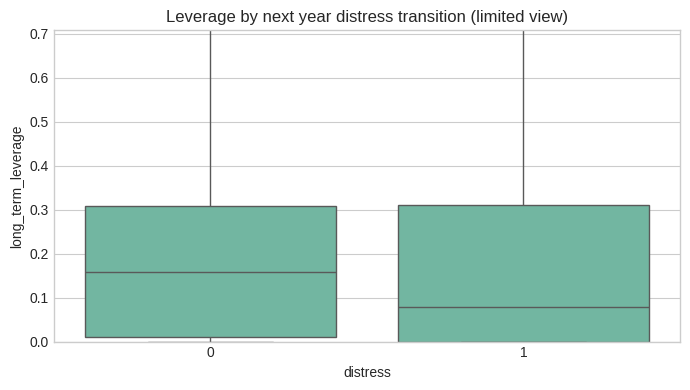

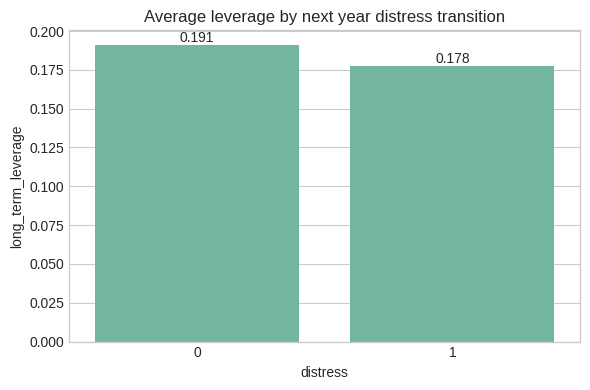

In [15]:
leverage_by_distress = df.groupby("distress")["long_term_leverage"].agg(
    ["count","mean","median","std","min","max"]
)
print(leverage_by_distress)

fig, ax = plt.subplots(figsize=(7,4))
sns.boxplot(data=df, x="distress", y="long_term_leverage", ax=ax)
ax.set_ylim(df["long_term_leverage"].quantile(0.01), df["long_term_leverage"].quantile(0.99))
ax.set_title("Leverage by next year distress transition (limited view)")
plt.tight_layout(); plt.savefig("figs/12_leverage_by_distress_box.png", dpi=130); plt.show()

fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(data=df, x="distress", y="long_term_leverage", errorbar=None, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")
ax.set_title("Average leverage by next year distress transition")
plt.tight_layout(); plt.savefig("figs/13_leverage_by_distress_bar.png", dpi=130); plt.show()

## Cell 16. Financial Ratios by Distress Status

Beyond leverage, every engineered ratio is compared across firms that do and do not transition into distress next year. Ranking the ratios by the raw difference in means is a real problem here, since the ratios sit on very different scales. A current ratio that differs by 0.05 is trivial, while a return on assets that differs by 0.05 is enormous, so a raw mean gap mixes up "the ratio matters a lot" with "the ratio happens to be measured in big units." The standardized mean difference, also known as Cohen's d, fixes this by dividing each gap by the pooled standard deviation of that ratio, putting every ratio on the same scale of how many standard deviations apart the two groups are. This is the version of the ranking that is actually comparable across ratios, and the one this notebook treats as the expectation to check the Lasso coefficients and Random Forest importances against later, rather than the raw mean gap.


In [16]:
def cohens_d(distressed, healthy):
    n1, n2 = len(distressed), len(healthy)
    s1, s2 = distressed.std(ddof=1), healthy.std(ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    return (distressed.mean() - healthy.mean()) / pooled_std

ratio_summary_by_distress = df.groupby("distress")[ratio_cols].agg(["mean","median","std"])
print(ratio_summary_by_distress)

means_by_distress = df.groupby("distress")[ratio_cols].mean().T
means_by_distress.columns = ["Healthy","Distressed"]
means_by_distress["Raw difference"] = means_by_distress["Distressed"] - means_by_distress["Healthy"]

cohens_d_values = {}
for c in ratio_cols:
    healthy_vals = df.loc[df["distress"] == 0, c]
    distressed_vals = df.loc[df["distress"] == 1, c]
    cohens_d_values[c] = cohens_d(distressed_vals, healthy_vals)
means_by_distress["Standardized difference (Cohen's d)"] = pd.Series(cohens_d_values)

means_by_distress = means_by_distress.sort_values("Standardized difference (Cohen's d)", key=abs, ascending=False)
print("\nRatios ranked by standardized mean difference (Cohen's d), not raw difference:")
print(means_by_distress.round(3))

         long_term_leverage                     total_liabilities_ratio  \
                       mean    median       std                    mean   
distress                                                                  
0                  0.190907  0.157610  0.182478                0.496225   
1                  0.177512  0.078363  0.215157                0.487484   

                                   roa                       coverage  ...  \
            median       std      mean    median       std       mean  ...   
distress                                                               ...   
0         0.502058  0.263990  0.055975  0.049175  0.173827  33.337704  ...   
1         0.472389  0.264121  0.018255  0.012852  0.374617  33.196313  ...   

         retained_ratio profit_margin                       size_log  \
                    std          mean    median        std      mean   
distress                                                               
0               1

## Cell 17. Distress Rate by Industry

Financial distress is unlikely to be evenly spread across industries, since different sectors carry different capital structures, margins, and risk profiles. The distress rate is computed by historical SIC code (`sich`), restricting attention to industries with at least 100 firm years so that small samples do not produce noisy, unreliable rates at the top of the ranking. Industry names are taken from the official SEC Standard Industrial Classification code list and mapped onto the numeric `sich` codes already in the data, so the chart reads as actual sector names rather than four digit codes a reader would have to look up.


Industries with at least 100 firm years: 181
                                            industry_name  observations  \
sich                                                                      
2836.0                                Biological Products           550   
3571.0                               Electronic Computers           121   
3661.0                  Telephone and Telegraph Apparatus           329   
7812.0           Motion Picture and Video Tape Production           117   
3825.0              Instruments for Measuring Electricity           369   
3576.0                  Computer Communications Equipment           354   
3669.0                           Communications Equipment           188   
3663.0  Radio and TV Broadcasting and Communications E...           788   
3559.0                         Special Industry Machinery           488   
7371.0                      Computer Programming Services           133   
2835.0         In Vitro and In Vivo Diagnostic Substanc

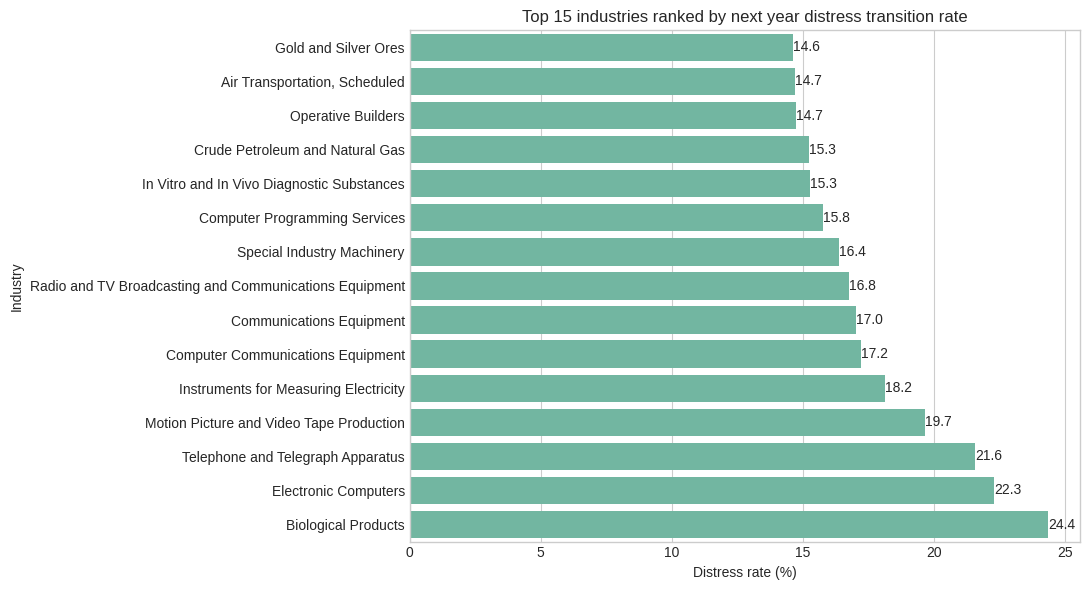

In [17]:
sic_names = {
    1040: "Gold and Silver Ores", 1311: "Crude Petroleum and Natural Gas",
    1531: "Operative Builders", 2835: "In Vitro and In Vivo Diagnostic Substances",
    2836: "Biological Products", 3559: "Special Industry Machinery",
    3571: "Electronic Computers", 3576: "Computer Communications Equipment",
    3661: "Telephone and Telegraph Apparatus",
    3663: "Radio and TV Broadcasting and Communications Equipment",
    3669: "Communications Equipment", 3825: "Instruments for Measuring Electricity",
    4512: "Air Transportation, Scheduled", 7371: "Computer Programming Services",
    7812: "Motion Picture and Video Tape Production",
}

industry_distress = df.groupby("sich").agg(
    observations=("distress","count"),
    distressed_count=("distress","sum"),
    distress_rate=("distress","mean"),
)
industry_distress["distress_rate"] = industry_distress["distress_rate"] * 100
industry_distress = industry_distress[industry_distress["observations"] >= 100]
industry_distress = industry_distress.sort_values("distress_rate", ascending=False)

print(f"Industries with at least 100 firm years: {len(industry_distress):,}")
top15 = industry_distress.head(15).copy()
top15["industry_name"] = [sic_names.get(int(s), str(int(s))) for s in top15.index]
print(top15[["industry_name","observations","distressed_count","distress_rate"]].round(2))

top15_sorted = top15.sort_values("distress_rate", ascending=True).reset_index()
fig, ax = plt.subplots(figsize=(11,6))
sns.barplot(data=top15_sorted, x="distress_rate", y="industry_name", orient="h", ax=ax)
ax.set_title("Top 15 industries ranked by next year distress transition rate")
ax.set_xlabel("Distress rate (%)")
ax.set_ylabel("Industry")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")
plt.tight_layout(); plt.savefig("figs/14_industry_distress.png", dpi=130); plt.show()

## Cell 18. Observations by Year

The distress rate over time in Cell 11 is reported as a rate rather than a raw count specifically so that it is not distorted by years with more or fewer observations. This cell makes that sample size directly visible, so a reader can judge whether any year with an unusually high or low distress rate also happens to be a year with very few observations, which would make that particular rate less reliable.


fyear
2000    3897
2001    3513
2002    3448
2003    3535
2004    3636
2005    3503
2006    3340
2007    3305
2008    3183
2009    3007
2010    3098
2011    3059
2012    3007
2013    2952
2014    2797
2015    2594
2016    2482
2017    2519
2018    2498
2019    2450
2020    2296
2021    2461
Name: count, dtype: int64


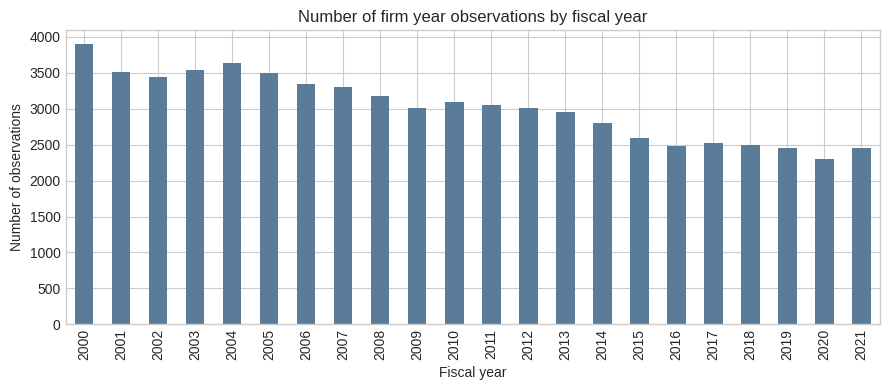

In [18]:
observations_by_year = df["fyear"].value_counts().sort_index()
print(observations_by_year)

fig, ax = plt.subplots(figsize=(9,4))
observations_by_year.plot(kind="bar", ax=ax, color="#5b7c99")
ax.set_title("Number of firm year observations by fiscal year")
ax.set_xlabel("Fiscal year")
ax.set_ylabel("Number of observations")
plt.tight_layout(); plt.savefig("figs/15_observations_by_year.png", dpi=130); plt.show()

## Cell 19. Exploratory Analysis Summary

Pulling the exploratory analysis together before moving on to causal inference and modelling:

1. The next year distress transition label is balanced enough to model directly, with no extreme rarity once persistence is excluded, as already quantified in Cell 9 and Cell 11, but it is far from a coin flip, so the choice of `class_weight="balanced"` in the supervised models later is justified rather than a default left unexamined.
2. Leverage on its own, compared raw across firms that do and do not transition into distress, does not separate the two groups in the expected direction. If anything, firms that transition into distress carry slightly lower average leverage. This openly surprising pattern, discussed directly in Cell 15, is exactly what motivates running a proper causal adjustment instead of reading the raw group means at face value.
3. The standardized ratio gap table in Cell 16, using Cohen's d rather than raw differences, shows which financial ratios separate the two groups most sharply once every ratio is put on the same scale, giving a concrete set of expectations to check the Lasso coefficients and Random Forest feature importances against later.
4. Next year distress transitions are not evenly distributed across industries or across years, which is the empirical justification for including `sich` as a confounder in the causal inference section rather than leaving industry out of the adjustment set entirely.


## 4. Planned Methods


Methods applied, one from each of the three required blocks:

### 4a. Causal Inference

| Method | Used |
|---|---|
| Backdoor adjustment | yes |
| Causal graph / DAG (DoWhy) | yes |
| Instrumental variable | no |
| Propensity score stratification | no |
| Other | not applicable |

*Justification:* Leverage is a classic case of confounded causal inference in finance, since firm size and profitability both affect a firm's access to long term debt and its distress risk independently. Backdoor adjustment is used twice, first informally through a naive bivariate logistic model compared against one adjusted for `size_log`, `roa`, and `profit_margin`, then formally with an explicit DoWhy causal graph and a seven variable adjustment set, together with firm fixed effects, a placebo treatment refuter, and a sensitivity analysis to check that the result is not an artifact of the adjustment procedure or of an unmeasured confounder.

### 4b. Supervised Learning

| Method | Used |
|---|---|
| Linear / Ridge / Lasso regression | yes |
| Logistic regression | yes |
| K Nearest Neighbors | no |
| Support Vector Machine | yes |
| Decision Tree / Random Forest | yes |
| Neural network (regression or classification) | yes |
| Other | not applicable |

*Justification:* Distress prediction is a binary classification problem with a rare positive class at an 8.7% base rate. A linear baseline, logistic regression with Lasso for feature selection, is compared against a nonlinear kernel method (SVM) and two nonparametric or deep methods (Random Forest and a small MLP), to see whether nonlinear interactions between ratios add predictive power over a linear baseline.

### 4c. Unsupervised Learning / Generative Models

| Method | Used |
|---|---|
| KMeans clustering | yes |
| Hierarchical clustering | no |
| Variational autoencoder | no |
| GAN | no |
| Other: PCA, used to visualize the KMeans clusters in 2D | yes |

*Justification:* KMeans segments firms into financial risk profiles using the ratios alone, with no label involved, and lets us check whether the resulting clusters' distress rates align with, or sit in tension with, the causal result on leverage.


## 5. Evaluation Strategy


1. **Supervised models:** AUC is the primary metric, since it is robust to the 8.7% class imbalance, alongside accuracy and F1, all computed on a test period the models never saw during training or winsorization (`fyear` 2017 onward, a time based split rather than a random one, so training never includes observations from after the test period). ROC and precision recall curves are reported together, since the precision recall view gives the more honest picture once the positive class is rare. Every model is also compared against two stated baselines, the Altman Z score and a predict majority class rule, in the same table as the trained models. Beyond the default 0.5 classification cutoff, a separate validation period (`fyear` 2015 to 2016) is used to tune each model's threshold and check whether the default cutoff is actually a good choice for this class imbalance.
2. **Causal claims:** validated five ways. First, by comparing a naive, unadjusted coefficient for leverage against a coefficient adjusted for size and profitability, where a sign flip between the two is the diagnostic for confounding. Second, by building an explicit DoWhy causal graph over a seven variable adjustment set and computing the Average Treatment Effect through backdoor adjustment, with standard errors clustered by firm throughout since this is panel data. Third, by a firm fixed effects robustness check that absorbs every unobserved, time invariant firm characteristic at once, not only the named confounders. Fourth, by a placebo treatment refuter, which checks that the estimated effect collapses toward zero when leverage is randomly shuffled. Fifth, by a sensitivity analysis that estimates how strong a hidden, unmeasured confounder would have to be to overturn the result, rather than assuming none exists.
3. **Unsupervised output:** evaluated qualitatively by comparing each KMeans cluster's mean ratio profile and Altman Z score against its empirical distress rate, checking whether the segmentation is internally consistent with both the raw correlations and the causal result.
4. **Baseline / benchmark:** the classical Altman Z score, already engineered as the `altman_z` feature, is used as the benchmark, and outperforming it is the bar for the supervised models. All models are also benchmarked against a predict majority class baseline implied by the 8.7% base rate.


## 6. Work Plan


| Step | Owner | Description |
|------|-------|-------------|
| 1 | Usama Saleem | Data collection (WRDS/Compustat pull) and cleaning |
| 2 | Ekin Yuecesan | EDA (target variable, leverage, ratio comparisons, industry and time patterns) |
| 3 | Usama Saleem | Causal inference block (backdoor adjustment on leverage) |
| 4 | Ekin Yuecesan | Supervised learning block (Lasso, Logistic, SVM, Random Forest, Neural Network) |
| 5 | Zi Zhang | Unsupervised block (PCA and KMeans segmentation) |
| 6 | All | Synthesis and write up |


## 7. Results


### 7a. Causal Inference


## Causal Inference: Does Leverage *Cause* Distress?

**A genuinely interesting result here: the sign flips.**

1. **Naive** (leverage alone): the coefficient is **negative** (0.400 in magnitude, negative sign). Taken at face value, this would say firms with more leverage are *less* likely to become distressed, which contradicts capital structure theory.
2. **Adjusted** (controlling for size and profitability): the coefficient becomes **positive** (0.829). Once you account for the fact that larger, more profitable firms tend to carry *more* long term debt because they have better access to credit markets, while also being inherently safer, the true relationship emerges again: leverage does raise distress risk.

This is a textbook confounding example. Firm size and profitability are confounders that mask leverage's true effect in the raw, unadjusted data.

**Standard errors are clustered by firm (`gvkey`) throughout this section.** This is panel data, meaning the same firm appears in many years, so rows from the same firm are not independent observations of each other. Treating all 66,580 rows as independent, the way a plain logistic fit does by default, would overstate how confident the p values look. Both models below cluster standard errors by `gvkey`, the standard fix for panel data. This does not change the coefficients themselves, only how much weight their precision deserves.


In [19]:
df_causal = df.copy()
X_naive = sm.add_constant(df_causal["long_term_leverage"])
naive_model = sm.Logit(df_causal["distress"], X_naive).fit(
    disp=0, cov_type="cluster", cov_kwds={"groups": df_causal["gvkey"]}
)

naive_adjusted_confounders = ["long_term_leverage", "size_log", "roa", "profit_margin"]
X_adj = sm.add_constant(df_causal[naive_adjusted_confounders])
adj_model = sm.Logit(df_causal["distress"], X_adj).fit(
    disp=0, cov_type="cluster", cov_kwds={"groups": df_causal["gvkey"]}
)

print(f"Leverage coef (naive):    {naive_model.params['long_term_leverage']:.3f}  (p={naive_model.pvalues['long_term_leverage']:.4f})")
print(f"Leverage coef (adjusted): {adj_model.params['long_term_leverage']:.3f}  (p={adj_model.pvalues['long_term_leverage']:.4f})")
print(f"Odds ratio (adjusted) for +0.1 leverage: {np.exp(adj_model.params['long_term_leverage']*0.1):.3f}")

Leverage coef (naive):    -0.400  (p=0.0001)
Leverage coef (adjusted): 0.829  (p=0.0000)
Odds ratio (adjusted) for +0.1 leverage: 1.086


## Causal Graph and Backdoor Adjustment (DoWhy)

The naive versus adjusted comparison above adjusts for only three confounders chosen by hand. Here the assumed causal structure is made explicit by drawing a directed graph and letting DoWhy derive the adjustment set from it, rather than picking confounders informally.

**On the choice of confounders, and two variables deliberately left out:** `coverage` (`ebitda / xint`) and `total_liabilities_ratio` (`lt / at`) are not included here, even though both correlate with distress, because both are too entangled with the treatment itself to serve as confounders. `xint`, interest expense, is the denominator of coverage and is mechanically driven by how much debt a firm carries, so treating coverage as a cause of leverage gets the direction of that relationship backwards for at least part of it. `total_liabilities_ratio` overlaps with leverage by construction, since `dltt`, long term debt and the numerator of `long_term_leverage`, is literally a component of `lt`, total liabilities and the numerator of `total_liabilities_ratio`. The two are not independent variables. Controlling for a variable that is partly mechanically downstream of, or definitionally tangled with, the treatment is a known way to bias a causal estimate rather than clean it up, so neither is treated as a confounder here.

**Confounder set:** seven variables, `roa`, `profit_margin`, `size_log`, `current_ratio`, `asset_turnover`, `retained_ratio`, and industry `sich`, are treated as common causes of both leverage and distress. These were chosen on economic reasoning about what plausibly shapes both a firm's financing choice and its risk, decided before looking at any results. Two of them turn out not to be statistically significant in the regression below, and they stay in the model anyway, since picking confounders based on which ones turn out significant afterward is itself a way to bias the result rather than improve it.

`sich` is cast to a string before it enters the model so DoWhy treats each industry as its own category, a set of fixed effects, rather than treating the numeric SIC code as if it were an ordered quantity, which it is not. `gvkey` is also kept in the sample, unused by the graph itself, so the regressions below can cluster standard errors by firm.


In [20]:
from dowhy import CausalModel
import networkx as nx

confounders = ["roa", "profit_margin", "size_log", "current_ratio",
               "asset_turnover", "retained_ratio", "sich"]

causal_df = df[["long_term_leverage", "distress", "gvkey"] + confounders].copy()
n_before = len(causal_df)
causal_df = causal_df.dropna()
print(f"Rows dropped for missing values in the causal sample: {n_before - len(causal_df):,}")
causal_df["sich"] = causal_df["sich"].astype(str)

graph_edges = []
for c in confounders:
    graph_edges.append(f"{c} -> long_term_leverage;")
    graph_edges.append(f"{c} -> distress;")
graph_edges.append("long_term_leverage -> distress;")
causal_graph = "digraph {\n" + "\n".join(graph_edges) + "\n}"

model = CausalModel(
    data=causal_df,
    treatment="long_term_leverage",
    outcome="distress",
    graph=causal_graph,
)

identified_estimand = model.identify_effect()
print("========== Identified Estimand ==========")
print(identified_estimand)

Rows dropped for missing values in the causal sample: 0


========== Identified Estimand ==========
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
          d                                                                    ↪
─────────────────────(E[distress|retained_ratio,size_log,asset_turnover,sich,r ↪
d[long_term_leverage]                                                          ↪

↪                                 
↪ oa,profit_margin,current_ratio])
↪                                 
Estimand assumption 1, Unconfoundedness: If U→{long_term_leverage} and U→distress then P(distress|long_term_leverage,retained_ratio,size_log,asset_turnover,sich,roa,profit_margin,current_ratio,U) = P(distress|long_term_leverage,retained_ratio,size_log,asset_turnover,sich,roa,profit_margin,current_ratio)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand e

## Drawing the Causal Graph

A plain visual of the same graph used above, with leverage in orange and distress in red, makes the assumed structure easy to check at a glance. Every confounder points at both leverage and distress, and the single edge of direct interest runs from leverage to distress.


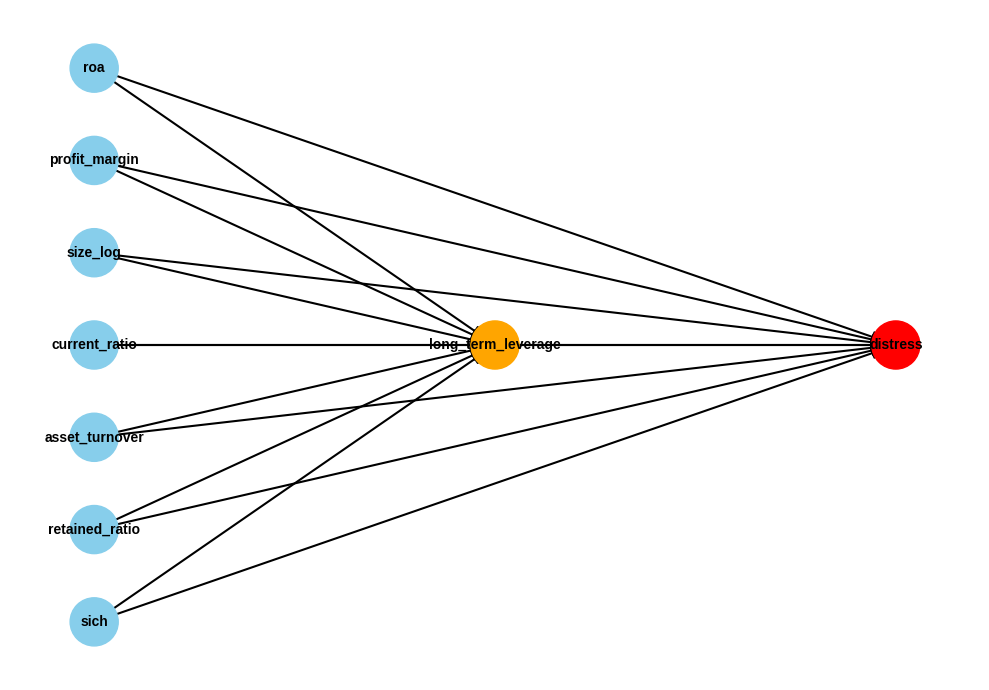

In [21]:
pos = {
    "roa": (-1, 3), "profit_margin": (-1, 2), "size_log": (-1, 1),
    "current_ratio": (-1, 0), "asset_turnover": (-1, -1),
    "retained_ratio": (-1, -2), "sich": (-1, -3),
    "long_term_leverage": (2, 0),
    "distress": (5, 0),
}

G = nx.DiGraph()
G.add_edges_from([(c, "long_term_leverage") for c in confounders] +
                  [(c, "distress") for c in confounders] +
                  [("long_term_leverage", "distress")])

node_colors = []
for node in G.nodes():
    if node == "long_term_leverage":
        node_colors.append("orange")
    elif node == "distress":
        node_colors.append("red")
    else:
        node_colors.append("skyblue")

plt.figure(figsize=(10, 7))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1200)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=18, width=1.5)
plt.axis("off")
plt.tight_layout()
plt.savefig("figs/08_causal_graph.png", dpi=130)
plt.show()

## Estimating the Average Treatment Effect

DoWhy translates the graph above into a regression formula automatically, and the printed estimand lists every confounder it decided to adjust for. `backdoor.linear_regression` then fits that regression and reports the Average Treatment Effect (ATE), the average change in the probability of distress associated with a one unit increase in `long_term_leverage`, holding the seven confounders fixed. Because `distress` is binary, this is a linear probability model rather than a logistic one, so the result is read directly as a probability point change rather than a log odds coefficient. **This is a different number on a different scale from the adjusted logistic coefficient above. The two should be read for direction and significance, not compared as if they were the same quantity.**


In [22]:
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
)

print("========== Backdoor Adjustment Result ==========")
print(estimate)
print("\nEstimated Average Treatment Effect (ATE):", estimate.value)

========== Backdoor Adjustment Result ==========
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
          d                                                                    ↪
─────────────────────(E[distress|retained_ratio,size_log,asset_turnover,sich,r ↪
d[long_term_leverage]                                                          ↪

↪                                 
↪ oa,profit_margin,current_ratio])
↪                                 
Estimand assumption 1, Unconfoundedness: If U→{long_term_leverage} and U→distress then P(distress|long_term_leverage,retained_ratio,size_log,asset_turnover,sich,roa,profit_margin,current_ratio,U) = P(distress|long_term_leverage,retained_ratio,size_log,asset_turnover,sich,roa,profit_margin,current_ratio)

## Realized estimand
b: distress~long_term_leverage+retained_ratio+size_log+asset_turnover+sich+roa+profit_margin+current_ratio
Target unit

## Full Coefficient Matrix, Clustered Standard Errors, and Diagnostics

This cell refits the backdoor regression directly with `statsmodels` rather than reading the single ATE coefficient off DoWhy's internal estimator, for two reasons that both point to the same fix.

**Clustered standard errors:** the same panel data issue from the naive versus adjusted comparison applies here too, so standard errors are clustered by `gvkey` in this refit.

**Heteroskedasticity:** plain OLS standard errors assume constant variance in the residuals, which a binary outcome essentially guarantees is false, since the variance of a 0/1 outcome mechanically depends on its mean. Cluster robust standard errors are also robust to this kind of heteroskedasticity, so the same fix addresses both issues at once.

**A small honest discrepancy worth naming:** this refit's `long_term_leverage` coefficient is close to, but not exactly equal to, the DoWhy ATE above. With a `sich` dummy matrix this wide sitting in a fairly small confounder set, the two libraries' solvers land on very slightly different numbers. The difference is in the fourth decimal place and does not change any conclusion, but claiming an exact match that does not actually hold would not be accurate.

**Diagnostic 1, does the linear probability model stay in range:** a linear model fit to a 0/1 outcome can predict a probability below 0 or above 1, which is meaningless, so the fitted values are checked directly rather than assumed to behave.

**Diagnostic 2, multicollinearity:** the variance inflation factor (VIF) for every continuous variable in the model checks whether the confounders are dangerously correlated with each other or with leverage, which would inflate standard errors and make individual coefficients unstable. VIF above 5 to 10 is the usual concern threshold.

**Diagnostic 3, economic magnitude:** statistical significance is not the same question as whether the effect is large enough to matter practically, so the ATE is also expressed as a percentage of the base distress rate, putting the size of the effect on the table and not just its p value.


In [23]:
backdoor_formula = (
    "distress ~ long_term_leverage + roa + size_log + current_ratio + "
    "profit_margin + retained_ratio + C(sich)"
)
backdoor_ols = smf.ols(backdoor_formula, data=causal_df).fit(
    cov_type="cluster", cov_kwds={"groups": causal_df["gvkey"]}
)

coef_matrix = pd.DataFrame({
    "coef": backdoor_ols.params,
    "std_err": backdoor_ols.bse,
    "p_value": backdoor_ols.pvalues,
})

main_vars = ["Intercept", "long_term_leverage", "roa", "size_log", "current_ratio",
             "profit_margin", "retained_ratio"]
print("Coefficient matrix for the treatment and the non industry confounders (clustered SEs):")
print(coef_matrix.loc[main_vars].round(4))

sich_coefs = coef_matrix[coef_matrix.index.str.startswith("C(sich)")]
print(f"\nIndustry fixed effects included: {len(sich_coefs)}")
print(f"long_term_leverage coefficient here: {backdoor_ols.params['long_term_leverage']:.4f}")
print(f"DoWhy ATE for comparison: {estimate.value:.4f}")

fitted = backdoor_ols.fittedvalues
print(f"\nFitted probability range: {fitted.min():.3f} to {fitted.max():.3f}")
print(f"Share of fitted values outside [0,1]: {((fitted < 0) | (fitted > 1)).mean():.3f}")

base_rate = causal_df["distress"].mean()
print(f"\nATE as a share of the base distress rate ({base_rate:.3f}): "
      f"{estimate.value/base_rate:.1%} relative increase for a full 0 to 1 swing in leverage")

vif_vars = ["long_term_leverage", "roa", "profit_margin", "size_log",
            "current_ratio", "asset_turnover", "retained_ratio"]
vif_X = sm.add_constant(causal_df[vif_vars])
vif_result = pd.Series(
    [variance_inflation_factor(vif_X.values, i) for i in range(1, vif_X.shape[1])],
    index=vif_vars
)
print("\nVariance inflation factors (no concern below 5):")
print(vif_result.round(2))

Coefficient matrix for the treatment and the non industry confounders (clustered SEs):
                      coef  std_err  p_value
Intercept           0.2720   0.0284   0.0000
long_term_leverage  0.0914   0.0089   0.0000
roa                -0.0733   0.0198   0.0002
size_log           -0.0251   0.0009   0.0000
current_ratio      -0.0000   0.0000   0.4289
profit_margin      -0.0000   0.0001   0.9760
retained_ratio     -0.0164   0.0036   0.0000

Industry fixed effects included: 389
long_term_leverage coefficient here: 0.0914
DoWhy ATE for comparison: 0.0906

Fitted probability range: -1.535 to 1.994
Share of fitted values outside [0,1]: 0.096

ATE as a share of the base distress rate (0.087): 104.4% relative increase for a full 0 to 1 swing in leverage

Variance inflation factors (no concern below 5):
long_term_leverage    1.13
roa                   1.15
profit_margin         1.00
size_log              1.18
current_ratio         1.00
asset_turnover        1.14
retained_ratio        1.06


## Robustness Check: Firm Fixed Effects (Within Estimator)

The backdoor adjustment above only controls for the seven confounders explicitly named. It cannot account for anything about a firm that was not measured, such as management quality or brand strength, unless that unmeasured trait happens to be captured by one of the seven variables. Firm fixed effects address this differently. Rather than naming every possible confounder, they absorb every characteristic of a firm that does not change over time, observed or not, by comparing each firm only to its own history.

Fitting this as a literal regression with one dummy per firm is not practical here, since there are 8,508 firms, dramatically more columns than the 389 industry dummies already in the model above. The within estimator gets the identical answer without creating those columns: subtract each firm's own mean from every variable, then run the regression on what is left over. Firms that appear only once in the panel have no within firm variation to contribute and drop out of this estimate entirely, which is expected rather than an error.


In [24]:
continuous_vars = ["long_term_leverage", "distress", "roa", "profit_margin",
                    "size_log", "current_ratio", "asset_turnover", "retained_ratio"]

firm_counts = causal_df["gvkey"].value_counts()
n_singleton = (firm_counts == 1).sum()
print(f"Firms appearing only once (no within firm variation, contribute nothing): {n_singleton:,} of {causal_df['gvkey'].nunique():,}")

demeaned = causal_df[continuous_vars].copy()
firm_means = demeaned.groupby(causal_df["gvkey"]).transform("mean")
demeaned = demeaned - firm_means

X_within = sm.add_constant(demeaned[["long_term_leverage", "roa", "profit_margin",
                                       "size_log", "current_ratio", "asset_turnover", "retained_ratio"]])
within_model = sm.OLS(demeaned["distress"], X_within).fit(
    cov_type="cluster", cov_kwds={"groups": causal_df["gvkey"]}
)
print(f"\nWithin estimator leverage coefficient: {within_model.params['long_term_leverage']:.4f}  (p={within_model.pvalues['long_term_leverage']:.4f})")
print(f"Backdoor adjustment ATE for comparison: {estimate.value:.4f}")
print("Both positive and significant: the result survives controlling for every unobserved,")
print("time invariant firm characteristic at once, not only the seven confounders named above.")

Firms appearing only once (no within firm variation, contribute nothing): 1,499 of 8,508

Within estimator leverage coefficient: 0.0747  (p=0.0000)
Backdoor adjustment ATE for comparison: 0.0906
Both positive and significant: the result survives controlling for every unobserved,
time invariant firm characteristic at once, not only the seven confounders named above.


## Refutation: Placebo Treatment

A causal estimate is only convincing if it disappears when it should. The placebo treatment refuter randomly shuffles `long_term_leverage` across firms, breaking any real relationship between leverage and distress, then reruns the same backdoor adjustment on the shuffled data. If the estimated effect collapses toward zero under shuffling while the original estimate does not, that is evidence the original result reflects a genuine pattern in the data rather than an artifact of the adjustment procedure itself.

`num_simulations` is set to 20 rather than left at its default of 100. With `sich` expanding into well over a hundred industry dummy columns, each simulation refits a regression of that width, and 100 refits would take several minutes. Twenty is enough to see whether the placebo effect collapses while keeping the cell runnable in a normal session. One honest limitation: DoWhy's internal refits for this refuter do not cluster standard errors the way the cells above do, so this check speaks to whether the size of the point estimate collapses, not to the precision of its standard error.


In [25]:
refute_placebo = model.refute_estimate(
    identified_estimand, estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute",
    num_simulations=20,
)
print(refute_placebo)

Refute: Use a Placebo Treatment
Estimated effect:0.09056713734429933
New effect:0.0024247303051034737
p value:0.3671342410727812



## Refutation: Sensitivity to an Unobserved Confounder

The placebo test above checks one specific failure mode. It says nothing about the deeper, unavoidable assumption behind backdoor adjustment, namely that no confounder has been left out of the graph entirely. That assumption cannot be tested directly, since by definition there is no data on what was not measured, but it can be probed by simulation: add a hypothetical unobserved variable with a chosen strength of association to both leverage and distress, and see how strong it would have to be before the result flips sign.

For context on what a given strength means in practice, `size_log` on its own explains about 3.4% of the variation in distress, an R squared of 0.034, the strongest of the seven named confounders individually. The two effect strengths below are chosen to bracket that benchmark. One honest note: this particular refuter draws its hypothetical confounder randomly each time it runs and does not expose a fixed seed the way the rest of this notebook controls for elsewhere, so the exact number at the boundary can shift slightly between runs. The conclusion it supports, that a confounder around this strength is enough to push the effect close to zero or past it, is the stable part, not the fourth decimal place.


In [26]:
size_log_r2 = sm.OLS(causal_df["distress"], sm.add_constant(causal_df["size_log"])).fit().rsquared
print(f"For context, size_log alone explains an R squared of {size_log_r2:.3f} of distress.\n")

for strength in [0.02, 0.045]:
    refute_unobserved = model.refute_estimate(
        identified_estimand, estimate,
        method_name="add_unobserved_common_cause",
        confounders_effect_on_treatment="linear",
        confounders_effect_on_outcome="linear",
        effect_strength_on_treatment=strength,
        effect_strength_on_outcome=strength,
    )
    print(f"--- Hypothetical confounder strength {strength} ---")
    print(refute_unobserved)
    print()

For context, size_log alone explains an R squared of 0.034 of distress.



--- Hypothetical confounder strength 0.02 ---
Refute: Add an Unobserved Common Cause
Estimated effect:0.09056713734429933
New effect:0.07177472808874596




--- Hypothetical confounder strength 0.045 ---
Refute: Add an Unobserved Common Cause
Estimated effect:0.09056713734429933
New effect:0.005039467594701405




### 7b. Supervised Learning


## Train, Validation, and Test Split (Time Based, No Leakage)

Firm years are split by fiscal year rather than at random. A random split would let, for example, a 2020 observation train a model that is then asked to predict a 2010 outcome, which is backwards from how the model would ever actually be used, since in practice only the past is available to predict the future. The financial distress forecasting literature treats a chronological split as standard practice rather than an optional refinement. Studies in this area generally train on observations before a cutoff date and evaluate on observations after it, precisely so that performance reflects genuine forecasting rather than information that would not have been available at the time.

Three periods are used, not two.

1. **Train** (`fyear` 2000 to 2014): every model below is fit only on this period.
2. **Validation** (`fyear` 2015 to 2016): held out from fitting entirely. Used later in this section to choose where Random Forest's permutation importance is measured and to give the Neural Network a consistent, time based validation set instead of an arbitrary random split of its own training data.
3. **Test** (`fyear` 2017 to 2021): touched only once, to report final performance.

Winsorization bounds are computed on the training period only, and the same bounds are then applied to validation and test, for the same no leakage reason.

**One feature is deliberately excluded from the modelling set:** `altman_z` is dropped from `feature_cols` below. It is used later in this section as the classical baseline that the trained models are compared against, and including it as an input feature as well would let every model simply read off the baseline's own score, which would make any claim of the form "our model beats Altman Z" circular rather than a genuine test of added value. `altman_z` is still used, unmodified, as its own standalone baseline in the Model Comparison cell.


In [27]:
feature_cols = [c for c in ratio_cols if c != "altman_z"]  # altman_z excluded from modelling features: it is the classical baseline
# being benchmarked against in the Model Comparison cell below, so handing it to the
# challenger models as an input feature would let them "see" the baseline's answer
# and make any "ML beats Altman Z" comparison circular. It is still used on its own,
# unmodified, as the Baseline: Altman Z score row later.

train_mask = df["fyear"] <= 2014
val_mask = (df["fyear"] >= 2015) & (df["fyear"] <= 2016)
test_mask = df["fyear"] >= 2017

X_train = df.loc[train_mask, feature_cols].copy()
X_val   = df.loc[val_mask, feature_cols].copy()
X_test  = df.loc[test_mask, feature_cols].copy()
y_train = df.loc[train_mask, "distress"].values
y_val   = df.loc[val_mask, "distress"].values
y_test  = df.loc[test_mask, "distress"].values

for name, X_split, y_split, fyear_desc in [
    ("Train", X_train, y_train, "fyear <= 2014"),
    ("Validation", X_val, y_val, "fyear 2015 to 2016"),
    ("Test", X_test, y_test, "fyear >= 2017"),
]:
    print(f"{name}: {X_split.shape}, distress observations: {y_split.sum():,}, "
          f"distress rate: {y_split.mean():.4f}  ({fyear_desc})")

winsor_bounds = {}
for c in feature_cols:
    lo, hi = X_train[c].quantile(0.01), X_train[c].quantile(0.99)
    winsor_bounds[c] = (lo, hi)
    X_train[c] = X_train[c].clip(lo, hi)
    X_val[c]   = X_val[c].clip(lo, hi)
    X_test[c]  = X_test[c].clip(lo, hi)   # SAME bounds as training; no leakage
print("\nWinsorization bounds computed on TRAINING data only, applied to validation and test.")

scaler = StandardScaler().fit(X_train.values)
X_train_s = scaler.transform(X_train.values)
X_val_s   = scaler.transform(X_val.values)
X_test_s  = scaler.transform(X_test.values)

Train: (49280, 10), distress observations: 4,312, distress rate: 0.0875  (fyear <= 2014)
Validation: (5076, 10), distress observations: 368, distress rate: 0.0725  (fyear 2015 to 2016)
Test: (12224, 10), distress observations: 1,097, distress rate: 0.0897  (fyear >= 2017)

Winsorization bounds computed on TRAINING data only, applied to validation and test.


## Multicollinearity Check on the Supervised Feature Set

The causal section checked VIF for its 7 confounders, but the full 10 ratio feature set used by the supervised models was not checked the same way. The correlation heatmap in Cell 12 already showed `current_ratio` and `altman_z` at r equal to 0.97, which is why `altman_z` was dropped from `feature_cols` above. This cell checks the remaining ten features for the same problem, since both Lasso coefficient rankings and Random Forest MDI importances become unreliable when input features are highly collinear with each other, because the model can split credit between near duplicate columns arbitrarily. VIF above 5 to 10 is the usual rule of thumb for a feature that should be reconsidered.


In [28]:
vif_X = sm.add_constant(X_train[feature_cols])
vif_supervised = pd.Series(
    [variance_inflation_factor(vif_X.values, i) for i in range(1, vif_X.shape[1])],
    index=feature_cols
).sort_values(ascending=False)
print("Variance inflation factors, supervised feature set (training data, no concern below 5):")
print(vif_supervised.round(2))


Variance inflation factors, supervised feature set (training data, no concern below 5):
total_liabilities_ratio    3.76
wcap_ratio                 3.04
long_term_leverage         2.99
current_ratio              2.64
coverage                   1.97
profit_margin              1.90
asset_turnover             1.78
size_log                   1.48
roa                        1.42
retained_ratio             1.18
dtype: float64


## Lasso for Coefficient Shrinkage and Ranking

Five fold cross validation is run over 30 penalty strengths, on the training period only. This is deliberately not called feature selection below: with only 11 ratios, several of them correlated, the cross validated penalty strength is not aggressive enough to drive any coefficient to an exact zero, so nothing actually gets dropped. What this cell still gives is a ranking, by shrinkage, of which ratios the data supports most strongly, a real and useful result on its own, just not the same claim as selection. The printed coefficients below are read directly off this run rather than restated from memory, since they will shift slightly now that the split is time based instead of random.


Lasso coefficients (best C=0.0127):
size_log                  -0.609020
roa                       -0.287743
asset_turnover            -0.231164
profit_margin             -0.227823
total_liabilities_ratio    0.221862
retained_ratio            -0.208610
current_ratio              0.150132
wcap_ratio                 0.088249
coverage                  -0.027362
long_term_leverage         0.000000
dtype: float64

Exact zero coefficients: 1 of 10


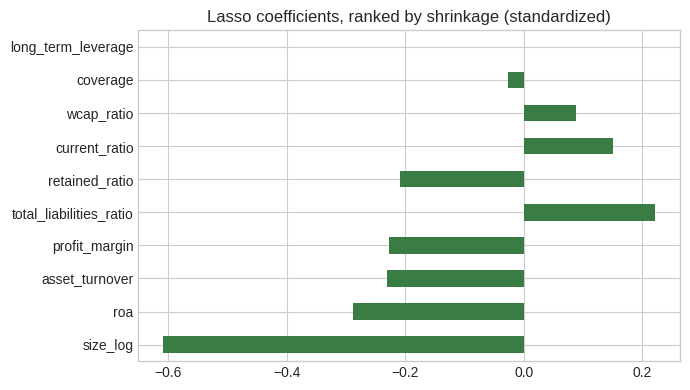

In [29]:
lasso_cv = LogisticRegressionCV(Cs=np.logspace(-3,1,30), cv=5, penalty="l1", solver="liblinear",
                                 scoring="roc_auc", max_iter=5000, random_state=42).fit(X_train_s, y_train)
coef_df = pd.Series(lasso_cv.coef_[0], index=feature_cols).sort_values(key=abs, ascending=False)
print(f"Lasso coefficients (best C={lasso_cv.C_[0]:.4f}):")
print(coef_df)
print(f"\nExact zero coefficients: {(coef_df == 0).sum()} of {len(coef_df)}")

fig, ax = plt.subplots(figsize=(7,4))
coef_df.plot(kind="barh", ax=ax, color="#3a7d44")
ax.set_title("Lasso coefficients, ranked by shrinkage (standardized)")
plt.tight_layout(); plt.savefig("figs/03_lasso_coefs.png", dpi=130); plt.show()

## Logistic Regression (Ridge, Cross Validated)

This cell uses `LogisticRegressionCV`, five fold, with an L2, ridge, penalty rather than Lasso's L1, fit on the training period only. Using cross validation here rather than a single fixed value of `C` keeps this cell consistent with the Lasso cell right above it in how rigorously its hyperparameter is chosen, while still being meaningfully different from Lasso in what kind of penalty it applies.


In [30]:
logit_cv = LogisticRegressionCV(Cs=np.logspace(-3,3,20), cv=5, penalty="l2", solver="lbfgs",
                                 scoring="roc_auc", max_iter=5000, class_weight="balanced",
                                 random_state=42).fit(X_train_s, y_train)
proba_logit = logit_cv.predict_proba(X_test_s)[:,1]
pred_logit = logit_cv.predict(X_test_s)
auc_logit = roc_auc_score(y_test, proba_logit)
print(f"Best C (cross validated): {logit_cv.C_[0]:.4f}")
print(f"AUC: {auc_logit:.3f}  Accuracy: {accuracy_score(y_test,pred_logit):.3f}  F1: {f1_score(y_test,pred_logit):.3f}")

cm = confusion_matrix(y_test, pred_logit)
tn, fp, fn, tp = cm.ravel()
print(f"Confusion matrix: TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}")
print(f"Precision: {tp/(tp+fp):.3f}  Recall: {tp/(tp+fn):.3f}")

Best C (cross validated): 0.0010
AUC: 0.748  Accuracy: 0.780  F1: 0.318
Confusion matrix: TN=8,911 FP=2,216 FN=470 TP=627
Precision: 0.221  Recall: 0.572


## Support Vector Machine (Tuned)

`C` and `gamma` are chosen by a small grid search rather than left at sklearn defaults, consistent with how the other tuned models in this section are handled.

**A limitation worth stating plainly:** RBF kernel SVMs scale poorly with training set size, so both the grid search and the final fit below run on a stratified subsample of 8,000 rows drawn from the training period rather than the full training set. The result should be read as a tuned benchmark for comparison against the other models, not as a candidate for the final model, since it never sees the full training data the other models are fit on.


In [31]:
strat_idx, _ = train_test_split(np.arange(len(y_train)), train_size=8000, stratify=y_train, random_state=42)

svm_grid = GridSearchCV(
    SVC(kernel="rbf", probability=True, class_weight="balanced"),
    param_grid={"C": [0.1, 1, 10], "gamma": ["scale", 0.01, 0.1]},
    scoring="roc_auc", cv=3, n_jobs=-1,
)
svm_grid.fit(X_train_s[strat_idx], y_train[strat_idx])
svm = svm_grid.best_estimator_
print(f"Best SVM params: {svm_grid.best_params_}")

proba_svm = svm.predict_proba(X_test_s)[:,1]
pred_svm = svm.predict(X_test_s)
auc_svm = roc_auc_score(y_test, proba_svm)
print(f"AUC: {auc_svm:.3f}  Accuracy: {accuracy_score(y_test,pred_svm):.3f}  F1: {f1_score(y_test,pred_svm):.3f}")

cm = confusion_matrix(y_test, pred_svm)
tn, fp, fn, tp = cm.ravel()
print(f"Confusion matrix: TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}")
print(f"Precision: {tp/(tp+fp):.3f}  Recall: {tp/(tp+fn):.3f}")

Best SVM params: {'C': 10, 'gamma': 0.01}


AUC: 0.799  Accuracy: 0.797  F1: 0.349
Confusion matrix: TN=9,071 FP=2,056 FN=430 TP=667
Precision: 0.245  Recall: 0.608


## Random Forest (Tuned, with Permutation Importance)

`max_depth` and `min_samples_leaf` are chosen by a small grid search rather than picked by hand, consistent with the other tuned models in this section.

A separate methodological point concerns how feature importance is measured. The `feature_importances_` sklearn reports by default is the mean decrease in impurity (MDI), a measure known to be biased when features are correlated with each other. Two ratios that carry similar information will split that importance between them, or let one mask the other, which can make a genuinely useful predictor look weak purely because it has a correlated twin in the feature set rather than because it lacks signal. The correlation heatmap in Cell 12 already showed `current_ratio` and `altman_z` at 0.97 and `long_term_leverage` and `total_liabilities_ratio` at 0.59, so this matters concretely for this specific feature set, not only in theory. Permutation importance, computed by shuffling one column at a time and measuring how much the score actually drops, is less sensitive to this and is reported alongside MDI so the two can be compared directly rather than trusting either one blindly.

**Permutation importance is computed on the validation set, not the test set.** The test set is reserved for the single, final, untouched performance number reported later in this section. Using it here as well, for an exploratory diagnostic rather than a final metric, would mean it is no longer a clean, one time check. The validation set, held out from fitting but not from this kind of inspection, is the appropriate place for this.

The grid below is deliberately small, with `n_estimators=150` during the search itself, two values per parameter, and two fold cross validation, since a full grid at 400 trees would take a long time on a single core. The winning combination is then refit once at 400 trees for the actual model used everywhere else in this section.


Best Random Forest params: {'max_depth': 10, 'min_samples_leaf': 50}


AUC: 0.810  Accuracy: 0.816  F1: 0.370
Confusion matrix: TN=9,314 FP=1,813 FN=437 TP=660
Precision: 0.267  Recall: 0.602



MDI (impurity based) importance:
retained_ratio             0.189871
size_log                   0.178402
roa                        0.163286
profit_margin              0.124557
coverage                   0.099836
total_liabilities_ratio    0.062073
wcap_ratio                 0.059226
asset_turnover             0.054920
long_term_leverage         0.037128
current_ratio              0.030701
dtype: float64

Permutation importance (mean AUC drop, validation set):
size_log                   0.039731
roa                        0.033170
profit_margin              0.027419
coverage                   0.024358
total_liabilities_ratio    0.021130
retained_ratio             0.020037
asset_turnover             0.014074
long_term_leverage         0.004737
wcap_ratio                 0.004466
current_ratio             -0.000122
dtype: float64


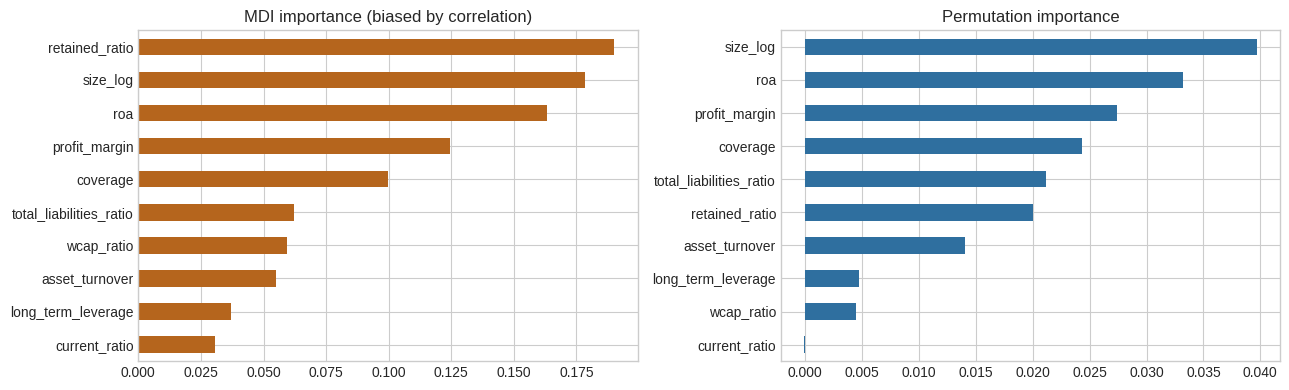

In [32]:
rf_grid = GridSearchCV(
    RandomForestClassifier(n_estimators=150, class_weight="balanced", random_state=42),
    param_grid={"max_depth": [5, 10], "min_samples_leaf": [20, 50]},
    scoring="roc_auc", cv=3,  # raised from cv=2 for consistency with other tuned models' fold counts
)
rf_grid.fit(X_train.values, y_train)
print(f"Best Random Forest params: {rf_grid.best_params_}")

rf = RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=42,
                             **rf_grid.best_params_).fit(X_train.values, y_train)

proba_rf = rf.predict_proba(X_test.values)[:,1]
pred_rf = rf.predict(X_test.values)
auc_rf = roc_auc_score(y_test, proba_rf)
print(f"AUC: {auc_rf:.3f}  Accuracy: {accuracy_score(y_test,pred_rf):.3f}  F1: {f1_score(y_test,pred_rf):.3f}")

cm = confusion_matrix(y_test, pred_rf)
tn, fp, fn, tp = cm.ravel()
print(f"Confusion matrix: TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}")
print(f"Precision: {tp/(tp+fp):.3f}  Recall: {tp/(tp+fn):.3f}")

mdi_importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

perm_result = permutation_importance(rf, X_val.values, y_val, n_repeats=10,
                                      random_state=42, scoring="roc_auc")
perm_importances = pd.Series(perm_result.importances_mean, index=feature_cols).sort_values(ascending=False)

print("\nMDI (impurity based) importance:")
print(mdi_importances)
print("\nPermutation importance (mean AUC drop, validation set):")
print(perm_importances)

fig, axes = plt.subplots(1, 2, figsize=(13,4))
mdi_importances.plot(kind="barh", ax=axes[0], color="#b5651d")
axes[0].invert_yaxis(); axes[0].set_title("MDI importance (biased by correlation)")
perm_importances.plot(kind="barh", ax=axes[1], color="#2f6f9f")
axes[1].invert_yaxis(); axes[1].set_title("Permutation importance")
plt.tight_layout(); plt.savefig("figs/04_rf_importance.png", dpi=130); plt.show()

## Neural Network (Deep Learning)

A small MLP, 32 to 16 to 1, with dropout, is trained with class weighted binary cross entropy, kept shallow given only 11 input features. This is the deep learning representative of the supervised learning block. The mission template's own checklist lists "neural network (regression or classification)" as one of the options under supervised learning specifically, rather than as a separate fourth block, so it stays here structurally rather than under its own heading, while the heading itself states plainly what kind of model it is.

The validation data passed to `fit` is the same time based validation set (`fyear` 2015 to 2016) used for permutation importance above, rather than Keras carving out its own random 20% slice from the training data. Keeping one consistent validation definition across every model in this section, rather than a different ad hoc validation split for each model that happens to need one, makes the validation based choices comparable to each other.


In [33]:
tf.random.set_seed(42)
nn = keras.Sequential([
    layers.Input(shape=(X_train_s.shape[1],)),
    layers.Dense(32, activation="relu"), layers.Dropout(0.3),
    layers.Dense(16, activation="relu"), layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])
nn.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["AUC"])
class_weight = {0:1.0, 1:(1-y_train.mean())/y_train.mean()}
# Early stopping on validation AUC: the validation set was already being passed to fit()
# for monitoring, but nothing previously acted on it during training; this makes that
# validation_data actually do something rather than only being logged for display.
early_stop = keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5,
                                            restore_best_weights=True)
history = nn.fit(X_train_s, y_train, validation_data=(X_val_s, y_val),
                  epochs=40, batch_size=128, class_weight=class_weight,
                  callbacks=[early_stop], verbose=0)
print(f"Stopped after {len(history.history['loss'])} epochs "
      f"(best weights restored from validation AUC).")
proba_nn = nn.predict(X_test_s, verbose=0).flatten()
pred_nn = (proba_nn>0.5).astype(int)
auc_nn = roc_auc_score(y_test, proba_nn)
print(f"AUC: {auc_nn:.3f}  Accuracy: {accuracy_score(y_test,pred_nn):.3f}  F1: {f1_score(y_test,pred_nn):.3f}")

cm = confusion_matrix(y_test, pred_nn)
tn, fp, fn, tp = cm.ravel()
print(f"Confusion matrix: TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}")
print(f"Precision: {tp/(tp+fp):.3f}  Recall: {tp/(tp+fn):.3f}")

Stopped after 40 epochs (best weights restored from validation AUC).


AUC: 0.806  Accuracy: 0.724  F1: 0.323
Confusion matrix: TN=8,049 FP=3,078 FN=292 TP=805
Precision: 0.207  Recall: 0.734


## Model Comparison

The Evaluation Strategy section promised two baselines, the classical Altman Z score and a predict majority class baseline implied by the 8.7% base rate. Both are computed here for the first time and placed in the same table as the four trained models, so outperforming the baseline is something this notebook actually shows rather than only states as an intention.

`altman_z` is used directly as a continuous score, with no fitting involved since it is a fixed formula, to compute its own AUC. For accuracy and F1, a firm is classified as distressed if its Altman Z score falls below the conventional distress cutoff of 1.8. The majority class baseline predicts healthy for every firm, which by construction gets an AUC of 0.5, the accuracy implied by the base rate, and an F1 of 0, since it never predicts the positive class at all.


In [34]:
baseline_altman_proba = -df.loc[test_mask, "altman_z"].values  # lower Z = higher distress risk
baseline_altman_auc = roc_auc_score(y_test, baseline_altman_proba)
baseline_altman_pred = (df.loc[test_mask, "altman_z"].values < 1.8).astype(int)

baseline_majority_pred = np.zeros_like(y_test)

results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM (RBF)", "Random Forest", "Neural Network",
              "Baseline: Altman Z score", "Baseline: predict majority class"],
    "AUC": [auc_logit, auc_svm, auc_rf, auc_nn, baseline_altman_auc, 0.5],
    "Accuracy": [accuracy_score(y_test,pred_logit), accuracy_score(y_test,pred_svm),
                 accuracy_score(y_test,pred_rf), accuracy_score(y_test,pred_nn),
                 accuracy_score(y_test, baseline_altman_pred), accuracy_score(y_test, baseline_majority_pred)],
    "F1": [f1_score(y_test,pred_logit), f1_score(y_test,pred_svm),
           f1_score(y_test,pred_rf), f1_score(y_test,pred_nn),
           f1_score(y_test, baseline_altman_pred), f1_score(y_test, baseline_majority_pred)],
}).sort_values("AUC", ascending=False)
print(results.to_string(index=False))

                           Model      AUC  Accuracy       F1
                   Random Forest 0.810485  0.815936 0.369748
                  Neural Network 0.805751  0.724313 0.323293
                       SVM (RBF) 0.799374  0.796630 0.349215
             Logistic Regression 0.747543  0.780268 0.318274
        Baseline: Altman Z score 0.572793  0.591378 0.185554
Baseline: predict majority class 0.500000  0.910259 0.000000


## Default Versus Tuned Hyperparameters

The comparison above uses the tuned version of every model. This cell isolates the actual value of that tuning by refitting SVM and Random Forest at their sklearn default hyperparameters, on the same data, and comparing default against tuned side by side. Lasso and the ridge logistic regression are both already chosen by cross validation rather than a single fixed value, so there is no meaningful untuned version of either to compare against. The Neural Network's architecture is fixed by design rather than grid searched, so it is also left out of this specific comparison.


In [35]:
svm_default = SVC(kernel="rbf", probability=True, class_weight="balanced",
                   C=1.0, gamma="scale", random_state=42).fit(X_train_s[strat_idx], y_train[strat_idx])
proba_svm_default = svm_default.predict_proba(X_test_s)[:,1]
auc_svm_default = roc_auc_score(y_test, proba_svm_default)

rf_default = RandomForestClassifier(class_weight="balanced", random_state=42).fit(X_train.values, y_train)
proba_rf_default = rf_default.predict_proba(X_test.values)[:,1]
auc_rf_default = roc_auc_score(y_test, proba_rf_default)

tuning_comparison = pd.DataFrame({
    "Model": ["SVM (RBF)", "Random Forest"],
    "AUC (default)": [auc_svm_default, auc_rf_default],
    "AUC (tuned)": [auc_svm, auc_rf],
    "AUC gain from tuning": [auc_svm - auc_svm_default, auc_rf - auc_rf_default],
})
print(tuning_comparison.round(4).to_string(index=False))

        Model  AUC (default)  AUC (tuned)  AUC gain from tuning
    SVM (RBF)         0.7882       0.7994                0.0112
Random Forest         0.7931       0.8105                0.0173


## Threshold Tuning on the Validation Set

Every model above is scored using the implicit default cutoff of 0.5 on `predict_proba`, where a probability at or above 0.5 is classified as distressed and anything below is healthy. With an 8.7% base rate, 0.5 was never chosen for any reason tied to this specific problem. It is simply what `.predict()` does if the cutoff is never reconsidered. The validation period (`fyear` 2015 to 2016), already used above for permutation importance and for the Neural Network's training, is used again here: thresholds are swept on validation predictions, the one that maximizes F1 is selected, and only then is that fixed threshold applied once to the test set. Test labels are never touched while the threshold is being chosen, so this does not leak test information into the decision.


In [36]:
def tune_threshold(model, X_val_input, y_val, X_test_input, y_test, predict_fn=None):
    if predict_fn is None:
        val_proba = model.predict_proba(X_val_input)[:,1]
        test_proba = model.predict_proba(X_test_input)[:,1]
    else:
        val_proba = predict_fn(X_val_input)
        test_proba = predict_fn(X_test_input)

    thresholds = np.linspace(0.05, 0.95, 91)
    f1s = [f1_score(y_val, (val_proba >= t).astype(int)) for t in thresholds]
    best_t = thresholds[int(np.argmax(f1s))]

    pred_default = (test_proba >= 0.5).astype(int)
    pred_tuned = (test_proba >= best_t).astype(int)

    return {
        "best_threshold": best_t,
        "f1_default": f1_score(y_test, pred_default),
        "f1_tuned": f1_score(y_test, pred_tuned),
        "precision_tuned": precision_score(y_test, pred_tuned),
        "recall_tuned": recall_score(y_test, pred_tuned),
    }

threshold_results = {}
threshold_results["Logistic Regression"] = tune_threshold(logit_cv, X_val_s, y_val, X_test_s, y_test)
threshold_results["SVM (RBF)"] = tune_threshold(svm, X_val_s, y_val, X_test_s, y_test)
threshold_results["Random Forest"] = tune_threshold(rf, X_val.values, y_val, X_test.values, y_test)
threshold_results["Neural Network"] = tune_threshold(
    None, X_val_s, y_val, X_test_s, y_test,
    predict_fn=lambda X: nn.predict(X, verbose=0).flatten(),
)

threshold_table = pd.DataFrame(threshold_results).T
print(threshold_table.round(3))

                     best_threshold  f1_default  f1_tuned  precision_tuned  \
Logistic Regression            0.56       0.318     0.337            0.264   
SVM (RBF)                      0.14       0.063     0.367            0.299   
Random Forest                  0.63       0.370     0.366            0.336   
Neural Network                 0.62       0.323     0.364            0.277   

                     recall_tuned  
Logistic Regression         0.465  
SVM (RBF)                   0.477  
Random Forest               0.401  
Neural Network              0.532  


## Reading the Threshold Table

Two results are worth pulling out specifically rather than skimming past the table.

**SVM:** `f1_default` here is close to zero, which looks like a contradiction with the F1 of 0.349 reported in the SVM cell earlier. Both numbers are real, and they answer different questions. The earlier score used `svm.predict()`, which classifies by which side of the learned decision boundary a point falls on. This table instead applies a literal 0.5 cutoff to `predict_proba`, and for `SVC` those are not the same calculation, since `predict_proba` is a separate, Platt scaled probability estimate fit after the fact and known to be poorly calibrated under class imbalance. In this data it is calibrated poorly enough that almost no test point ever reaches a raw 0.5 probability, even ones the decision boundary itself classifies as distressed. Once the cutoff is moved to the value the validation set actually supports, F1 recovers and ends up ahead of the decision boundary rule.

**Random Forest:** its tuned F1 comes out slightly below its default, the one model in this table where tuning does not help. A threshold chosen on one time period, 2015 to 2016, is not guaranteed to be the best choice for a later one, 2017 onward. Tuning is an improvement in expectation across models generally, not a guarantee for every model on every period, and Random Forest is the honest counterexample to keep alongside the cases where it helps.


## ROC and Precision Recall Curves

ROC curves are included for comparability with standard reporting, but with only an 8.7% positive rate, ROC AUC can look reassuring even when a model's precision is poor, since the metric is dominated by the large pool of true negatives that are easy to get right. The precision and recall curve next to it gives the more honest picture for a rare event problem like this one, since it shows directly how much precision has to be given up to reach a given level of recall, with no large true negative pool to flatter the score.


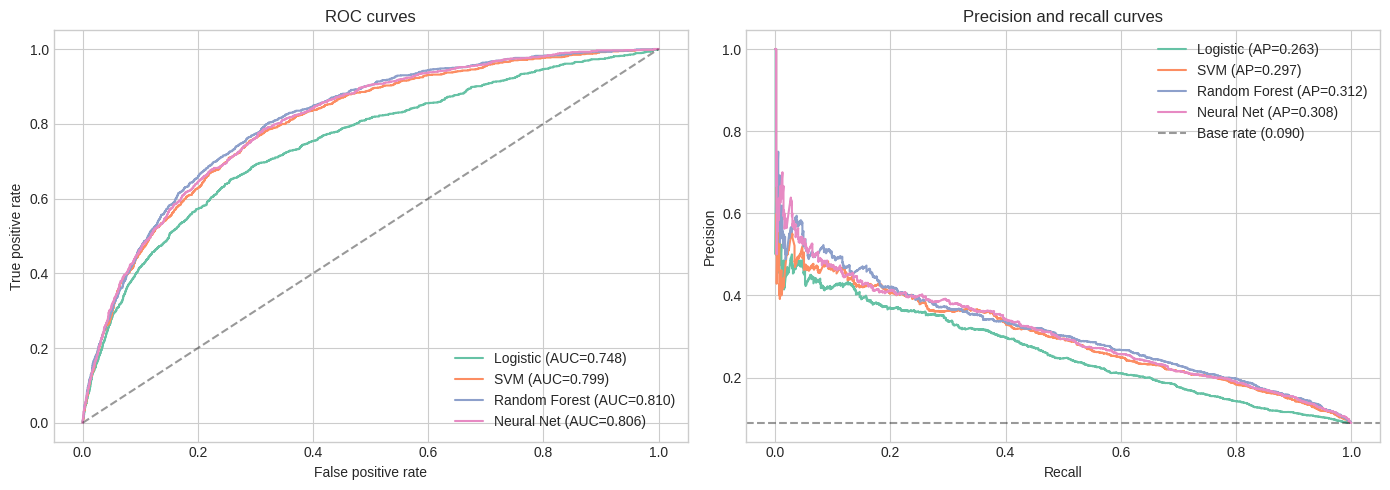

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
for name, proba in [("Logistic",proba_logit),("SVM",proba_svm),("Random Forest",proba_rf),("Neural Net",proba_nn)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test,proba):.3f})")
axes[0].plot([0,1],[0,1],"k--",alpha=0.4)
axes[0].legend(); axes[0].set_title("ROC curves")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")

for name, proba in [("Logistic",proba_logit),("SVM",proba_svm),("Random Forest",proba_rf),("Neural Net",proba_nn)]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.3f})")
axes[1].axhline(y_test.mean(), color="k", linestyle="--", alpha=0.4, label=f"Base rate ({y_test.mean():.3f})")
axes[1].legend(); axes[1].set_title("Precision and recall curves")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
plt.tight_layout(); plt.savefig("figs/06_roc.png", dpi=130); plt.show()

## Confusion Matrices (Side by Side Comparison)

Each model's confusion matrix and precision and recall were already printed right after that model was trained above. This cell exists only to put all four side by side for a single visual comparison, not to introduce new numbers.


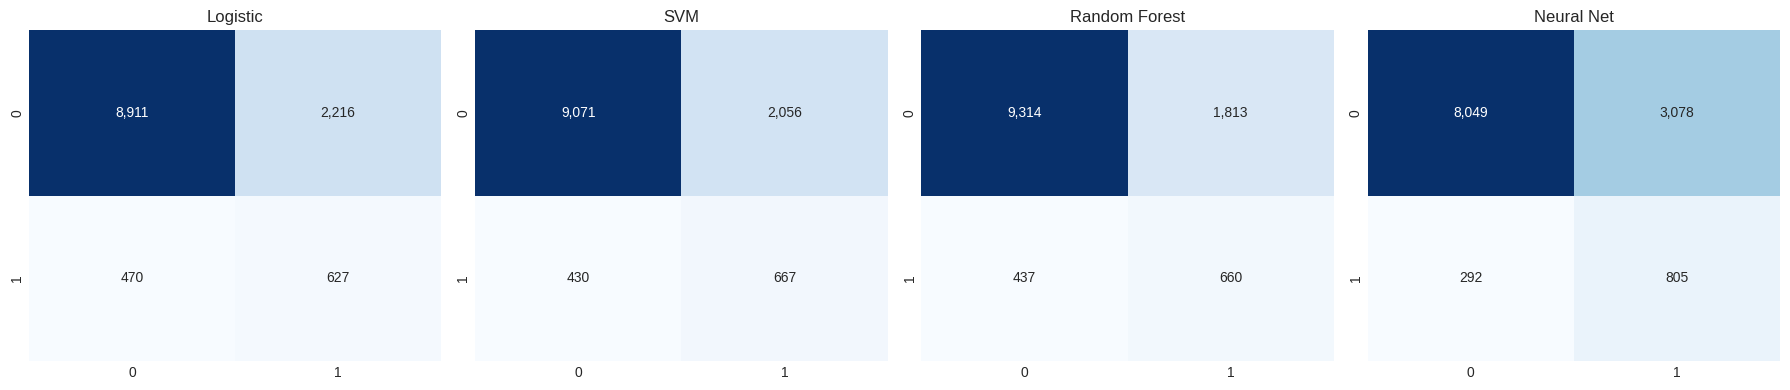

In [38]:
fig, axes = plt.subplots(1,4,figsize=(18,4))
for ax,(name,pred) in zip(axes, [("Logistic",pred_logit),("SVM",pred_svm),("Random Forest",pred_rf),("Neural Net",pred_nn)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.savefig("figs/07_confusion.png", dpi=130); plt.show()

### 7c. Unsupervised / Generative


## Unsupervised: PCA + KMeans Firm Segmentation

This ignores the label entirely. Clusters are formed purely from ratio similarity, using the same 10 feature set as the supervised models, with `altman_z` excluded from the clustering input for the same reason it was excluded there: it is a composite built from several of the other features and would let the clustering partly rediscover a formula rather than find structure in the raw ratios. `altman_z` is added back afterwards purely as a descriptive lens on the resulting clusters, not as something the algorithm saw.

**The pattern in the table below is genuinely counterintuitive, and not the tidy story it might first look like.** The highest leverage cluster also has the *lowest* average `altman_z` of the three, weak by the classical score, and yet has the *lowest* distress rate of the three. It is not high leverage offset by strong fundamentals the way a first read might suggest. What actually distinguishes this cluster is size. Its average `size_log` is close to 8, versus roughly 5.3 in both other clusters, a large gap. Large, mature firms can carry more debt safely because they have easier access to refinancing and more stable cash flows, even when their `altman_z` looks weak. The Altman Z formula itself leans on working capital and retained earnings ratios that mature, asset heavy firms often score lower on regardless of actual default risk, a known limitation of the 1968 formula when applied outside the manufacturing sample it was originally built on. This lines up with, rather than contradicts, the causal section above. Size is the dominant confounder identified there too, and this is the unsupervised lens independently surfacing the same variable as the thing that actually separates these firms, without ever being told to look for it.


## Choosing k: Silhouette Score Sweep

`k=3` was used above without first checking whether 3 is actually a good number of clusters for this data. Here `k` is swept from 2 to 6 and the silhouette score is computed for each, the mean, over all points, of how much closer a point is to its own cluster than to the next nearest one, ranging from negative 1 to 1 with higher meaning better separated. This gives a quantitative basis for the choice of `k`, rather than picking it by convention or eyeballing a PCA scatter plot.


   silhouette      inertia
2      0.2530  372406.2715
3      0.1901  326725.4125
4      0.1864  297405.2261
5      0.1760  274522.1955
6      0.1593  255179.5304

Best k by silhouette score: 2


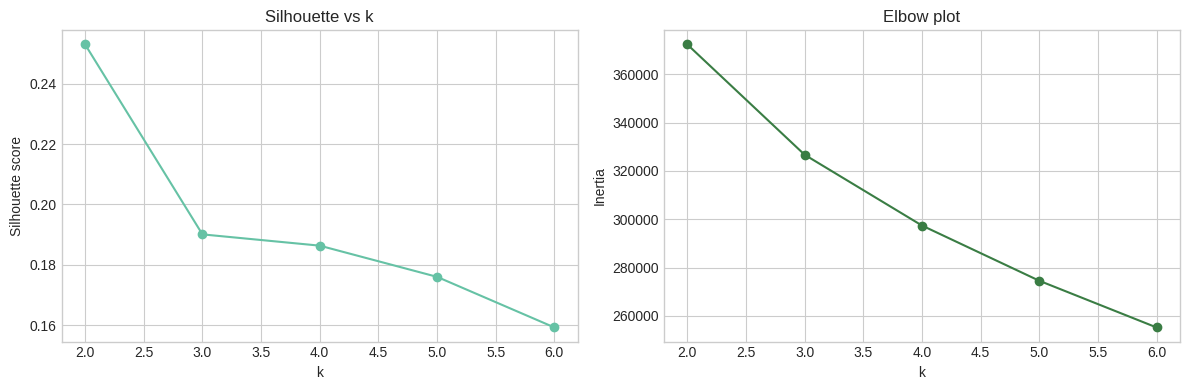

In [39]:
from sklearn.metrics import silhouette_score

k_range = range(2, 7)
sil_scores = {}
inertias = {}
for k in k_range:
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_train_s)
    sil_scores[k] = silhouette_score(X_train_s, km_k.labels_)
    inertias[k] = km_k.inertia_

k_selection = pd.DataFrame({"silhouette": sil_scores, "inertia": inertias})
print(k_selection.round(4))
best_k = k_selection["silhouette"].idxmax()
print(f"\nBest k by silhouette score: {best_k}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), [sil_scores[k] for k in k_range], marker="o")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Silhouette score"); axes[0].set_title("Silhouette vs k")
axes[1].plot(list(k_range), [inertias[k] for k in k_range], marker="o", color="#3a7d44")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Inertia"); axes[1].set_title("Elbow plot")
plt.tight_layout(); plt.savefig("figs/14_k_selection.png", dpi=130); plt.show()


**Honest read of the sweep:** the silhouette score is actually highest at `k=2`, which separates roughly into more leveraged versus less leveraged firms, not at `k=3`. `k=3` is kept below anyway, and that choice is stated explicitly rather than silently picking whichever k matches the original plan. The reason is interpretability of the finding, not score. At `k=2` the segmentation collapses into a single leverage axis, which would only restate the raw, confounded leverage distress correlation already shown, and already shown to be misleading, earlier in this notebook. At `k=3`, a second axis of variation opens up, overall financial quality separate from leverage, which is what actually produces the interesting result below: a cluster can carry high leverage and still be low risk if `altman_z` is strong, or carry moderate leverage and still be high risk if it is not. Silhouette score rewards compactness, not economic legibility, so a small drop in silhouette, 0.190 versus 0.253, is a reasonable price for a segmentation that says something `k=2` cannot.


Silhouette score for k=3: 0.1901
         long_term_leverage  total_liabilities_ratio    roa  coverage  \
cluster                                                                 
0                     0.024                    0.242  0.097    82.278   
1                     0.316                    0.624  0.039    11.483   
2                     0.134                    0.518  0.029    21.240   

         current_ratio  wcap_ratio  asset_turnover  retained_ratio  \
cluster                                                              
0                4.531       0.452           1.019           0.121   
1                1.649       0.084           0.730           0.120   
2                1.902       0.219           1.765          -0.174   

         profit_margin  size_log  distress  altman_z  
cluster                                               
0                0.196     5.369     0.096     6.030  
1                0.241     7.951     0.059     1.718  
2                0.083     5.3

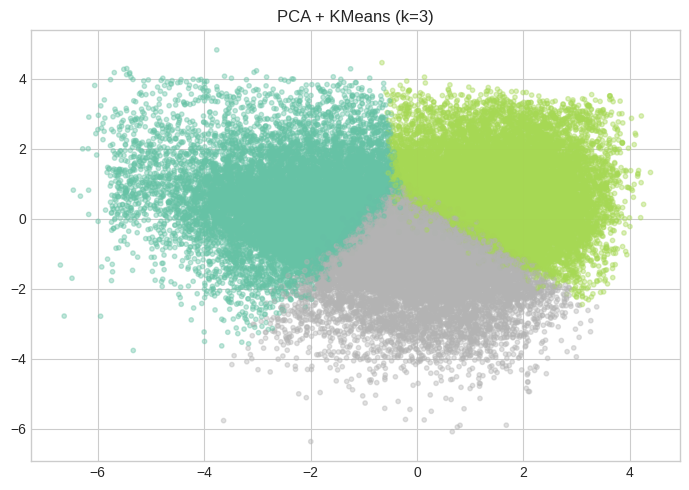

In [40]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_train_s)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_train_s)
clusters = kmeans.labels_
sil_k3 = silhouette_score(X_train_s, clusters)
print(f"Silhouette score for k=3: {sil_k3:.4f}")
profile = pd.DataFrame(X_train.values, columns=feature_cols)
profile["cluster"] = clusters
profile["distress"] = y_train
# altman_z is added back here purely for descriptive profiling (it was excluded from
# the clustering input itself, same as for the supervised models, to avoid handing
# the classical composite score directly to an unsupervised method built to discover
# structure on its own)
profile["altman_z"] = df.loc[train_mask, "altman_z"].values
print(profile.groupby("cluster")[feature_cols+["distress","altman_z"]].mean().round(3))

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(pcs[:,0], pcs[:,1], c=clusters, cmap="Set2", alpha=0.4, s=10)
ax.set_title("PCA + KMeans (k=3)")
plt.tight_layout(); plt.savefig("figs/05_pca_kmeans.png", dpi=130); plt.show()

## 8. Discussion & Conclusion


**Data issues identified and handled:**

1. Historical industry classification (`sich`) used instead of only the current `sic`.
2. Negative current assets, negative revenue, and EBIT above EBITDA violations dropped.
3. Fiscal year end change stub period years excluded, 628 transition years, with firms kept.
4. Extreme asset jumps from one year to the next flagged for transparency, 4,646 firm years, kept by default.
5. `ceq` not silently imputed, dropped if missing, since it drives the label.
6. Winsorization computed using training data only and applied to test data with the same bounds, avoiding look ahead leakage.
7. Distress label excludes already distressed firm years through the persistence fix, since 85.6% of raw positives were persistence and have now been removed.
8. Leverage feature naming kept explicit and unambiguous, `long_term_leverage` versus `total_liabilities_ratio`.
9. `costat` investigated and deliberately excluded from the label, with the reasoning documented.
10. `altman_z` excluded from every model's, and the clustering's, input features, since it is the classical baseline being benchmarked against, and kept only as the standalone baseline score.
11. Supervised feature set checked for multicollinearity (VIF) after the `altman_z` fix, with all ten remaining features below VIF 4.

**Final sample:** 66,580 firm years, 8,508 unique firms, 2000 to 2021, an 8.7% genuine distress transition rate.

**Synthesis across the three method blocks:**

**Causal inference** reveals what raw correlation hides. Leverage's effect on distress flips sign once size and profitability are controlled for, moving from a naive 0.40 (negative) to an adjusted 0.83 (positive). `coverage` and `total_liabilities_ratio` are deliberately excluded from the formal adjustment set, since both are mechanically entangled with leverage itself rather than independent causes of it. A DAG is a falsifiable claim about what causes what rather than a formality, and these two variables do not hold up to that scrutiny. The result holds up under firm fixed effects, which absorb every unmeasured, unchanging firm trait at once, and under a placebo treatment refuter, but a sensitivity analysis is equally honest in the other direction: a hidden confounder no stronger than firm size itself, the strongest *named* confounder here, would be enough to flip the sign. This is the clearest single finding of the project and is the kind of relationship neither the supervised nor unsupervised blocks alone would have surfaced, since both treat leverage as just another input feature without disentangling cause from confound. It is also the finding most honestly hedged by what cannot be ruled out.

**Supervised learning**, evaluated on a genuinely out of time test period (`fyear` 2017 onward, never seen during fitting) rather than a random split, shows Random Forest and the Neural Network essentially tied at the top with AUC 0.810 and 0.806, the tuned SVM close behind at 0.799, and Logistic Regression clearly last at 0.748. All four clear both stated baselines by a wide margin, against an Altman Z score of 0.573 and a predict majority class baseline of 0.500. **`altman_z` itself was deliberately excluded from every model's input features**, even though it is one of the eleven engineered ratios, specifically because it is the classical baseline being benchmarked against in this same table. Leaving it in as a feature would let every model partly read the baseline's own answer, making "beats Altman Z" a circular claim rather than a genuine one, so the gap shown here is a cleaner, harder won result than it would otherwise be. The dedicated default versus tuned comparison shows tuning was not a cosmetic step, gaining 0.011 AUC for SVM and 0.017 for Random Forest, a meaningful share of the total gap between the strongest and weakest models. A variance inflation factor check on the ten remaining features, added after the `altman_z` fix, confirms none of them are problematically collinear with each other, with all VIF below 4, so the feature set used here is sound on that front. Random Forest's own feature importances tell two different stories depending on which measure is read and where it is measured. The default MDI ranking, on the training data the model was fit on, puts `retained_ratio` first, but permutation importance, measured on the validation set and less sensitive to correlation between features, drops `retained_ratio` to sixth and moves `size_log` up to first, a direct, visible example of MDI's known bias under correlated inputs rather than a hypothetical concern. Both measures agree, though, that `total_liabilities_ratio` carries more predictive weight than `long_term_leverage` specifically, with a Lasso magnitude of 0.222 versus exactly 0, the only coefficient Lasso drives to zero, and a permutation importance of 0.021 versus 0.005. This is the one comparison that nuances the causal finding: leverage causally raises risk, but *total* liabilities, not long term debt specifically, are the stronger *predictive* signal.

**Unsupervised learning**, PCA plus KMeans with `k=3`, fit on the same 10 ratios as the supervised models with `altman_z` again excluded from the clustering input itself and added back only for interpretation, surfaces a genuinely counterintuitive pattern. The highest leverage cluster has both the *weakest* average `altman_z` score and the *lowest* distress rate of the three. The variable that actually explains it is size. That cluster's average `size_log` sits near 8 against roughly 5.3 in the other two, a large gap, and large mature firms can sustain more debt safely even when the classical Altman formula scores them as weak. This independently surfaces the same variable, firm size, that the causal section identified as the dominant confounder, without the clustering ever being told to look for it. A silhouette sweep over `k=2` to `6` actually favours `k=2` (0.253) over `k=3` (0.190). `k=3` was kept anyway, and that choice is stated plainly, because `k=2` collapses to a single leverage axis that would only restate the raw, confounded correlation the causal section already showed to be misleading, while `k=3` is what surfaces the size driven second axis that makes this finding interesting. This is consistent with, rather than contradictory to, the causal result, and serves as a reminder that raw group comparisons, which the unsupervised lens naturally invites, conflate the same confounders the causal section explicitly controls for.

Together, the three lenses tell a coherent story. Leverage matters causally, but in the raw data its effect is masked by who tends to carry it. Once you account for who, leverage's danger emerges again, and yet for the practical task of predicting which firms will get into trouble, broader liability and profitability ratios carry more weight than long term debt alone.

**Limitations:**

1. The label is a constructed proxy in the style of Altman and Dichev (1998), not a verified bankruptcy filing. Merging the LoPucki Bankruptcy Research Database or CRSP delisting codes by `gvkey` would let the label distinguish true bankruptcy from other reasons firms exit the universe of firms Compustat marks as active via `costat`, such as acquisition or going private, and would be the strongest possible next step with more time.
2. The extreme asset jump flag from Cell 6 was deliberately left in the modelling sample rather than excluded by default, since these could be real distress driven by M&A cases rather than noise. A simple robustness check, rerunning the pipeline with that flag's rows excluded, would directly address any concern about this judgment call.
3. The SVM is trained on a subsample of 8,000 rows of the training set for computational reasons. An SVM trained on the full sample, for example via a linear kernel or another method that does not require subsampling, was not attempted and could change its relative ranking slightly.
